# Bayesian Optimisation: ERK CNR-AUC (v13 — fixed light budget, auc_norm objective)

v13 is the clean iteration of the v11 -> v12 arc.

| Notebook | BO objective | Search space |
|---|---|---|
| `...v11_light_budget` | `frac_responders` (fixed dose) | `ramp_fraction x pulse_interval` at fixed budget |
| `...v12_light_budget_auc` | `auc_per_light` (ratio) | `light_budget x ramp_fraction x pulse_interval` |
| `...v13_auc_fixed_budget` (this) | **`auc_norm`** | **`ramp_fraction x pulse_interval`** at fixed budget |

**Why v13.**  v11's `frac_responders` saturates at 1.0 — many conditions hit
the ceiling, the GP turns pathologically over-confident there, and Expected
Improvement collapses (nothing beats 1.0) so the BO degenerates in late
phases.  v12 tried `auc_per_light`, but a *ratio* objective is heteroscedastic
(variance scales as 1/budget^2), is pulled to the minimum-budget boundary by
the small denominator, and makes the GP waste capacity fitting the
deterministic 1/B law.

v13 fixes both:

1. **Objective = `auc_norm`** — per-FOV median per-cell *normalized* CNR-AUC
   above baseline.  For each cell, divide its CNR trace by its own baseline
   (mean over the first 10 frames) so the trace is on a fold-change scale,
   subtract 1, sum over the stim + recovery window, clip negative at 0.
   The per-cell normalization removes the baseline-magnitude confound: a 2x
   fluctuation contributes the same auc_norm regardless of basal CNR, so the
   BO sees a biologically interpretable fold-change metric on a roughly
   homoscedastic scale.  Unbounded above => no ceiling pathology.  The
   absolute `auc_above_baseline` is still recorded as a diagnostic.
2. **Light budget pinned at `FIXED_LIGHT_BUDGET_MS`.**  Not a BO axis.  The BO
   searches the 2-D `(ramp_fraction, pulse_interval)` grid — how to
   *distribute* a fixed dose.  This removes v12's ratio entirely;
   with the budget pinned every condition spends the same dose, so an
   efficiency metric carries no extra information and isn't recorded.

**`auc_norm` (per FOV).**  For each cell passing the quality gates
(tracked >= 80 % of frames, baseline CNR < 1.0):

```
baseline_cell = mean(CNR_t for t in baseline frames)     # first 10 frames
cnr_norm(t)   = CNR_t / baseline_cell                     # fold change vs baseline
auc_norm_cell = sum(cnr_norm(t) - 1)                      # integrated fold-excess
                   over t in [first_frame_stim, n_frames)
auc_norm_cell = max(0, auc_norm_cell)                     # clip negative cells to 0
auc_norm      = median over valid cells of auc_norm_cell
```

Equivalently, `auc_norm_cell = absolute_auc_cell / baseline_cell` — dividing
by the per-cell baseline turns the absolute change into a fold change.  The
absolute version is still recorded as `auc_above_baseline` for post-hoc
comparison.

**Phase-0 readiness gate.**  Cells are ERK-active from the handling stress of
loading the plate; CNR decays over hours in starvation medium.  Instead of a
fixed guessed wait, a `FOVConditionMonitorAgent` images a *sacrificial* well
every 20 min and starts the experiment once 75 % of cells have CNR < 1.0 (or a
20 h timeout).  The BO then runs on fresh wells.

> **Caveat to keep on the slide.**  `auc_above_baseline` rewards *sustained*
> ERK; a cell oscillating around baseline integrates to ~ 0.  v13 is a clean
> BO demonstration and a response-*magnitude* experiment — it is not the
> oscillation question.  Do not let "AUC" stand in for "oscillation".

In [1]:
import os
import time
import logging
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suppress JAX/XLA debug messages
os.environ["JAX_LOG_COMPILES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import jax

jax.config.update("jax_log_compiles", False)
for _name in list(logging.Logger.manager.loggerDict):
    if "jax" in _name or "absl" in _name:
        logging.getLogger(_name).setLevel(logging.WARNING)

# ---------------------------------------------------------------------------
# gpax/numpyro compatibility shim
# ---------------------------------------------------------------------------
# numpyro >= 0.20 removed haiku support from numpyro.contrib.module, but
# gpax 0.1.9 eagerly imports viDKL via gpax/models/__init__.py, which tries
# `from numpyro.contrib.module import random_haiku_module, haiku_module`.
# We don't use viDKL (only ExactGP, viGP, viSparseGP), so we install stubs
# that raise only if viDKL is actually called. This MUST run before any
# `import gpax` (including the lazy ones inside the BO agent classes).
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_args, **_kwargs):
    raise NotImplementedError(
        "haiku support was removed from numpyro >= 0.20. "
        "viDKL is not available. Use ExactGP, viGP, or viSparseGP."
    )


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable
# ---------------------------------------------------------------------------

from faro.core.data_structures import (
    PowerChannel,
    SegmentationMethod,
)
from faro.core.controller import Controller
from faro.core.pipeline import ImageProcessingPipeline
from faro.agents.bo_optimization import (
    BO_Parameter,
    BO_Objective,
    BO_Covariate,
)
from faro.agents.bo_oscillation import OscillationBO
import faro.core.utils as utils

## Microscope & pipeline setup

**Microscope:** Jungfrau (no DMD -- full-FOV stimulation).

**Channels:**
- Imaging: miRFP (nuclear marker) + mScarlet3 (ERK-KTR reporter)
- Stimulation: CyanStim (optogenetic activation, power 10)
- Optocheck: mCitrine (verify optoRTK expression, last frame only)

**Pipeline:** CellposeV4 segmentation -> ERK-KTR FE -> Trackpy tracking
-> OptoCheckFE on reference frames. Full-FOV stimulation (no DMD).

In [2]:
from faro.microscope.pertzlab.jungfrau import Jungfrau

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")

In [3]:
mic.mmc.setProperty("TIPFSStatus", "State", "On")

In [3]:
import napari
from napari_micromanager import MainWindow

viewer = napari.Viewer()
mm_wdg = MainWindow(viewer)
mm_wdg._mmc = mic.mmc  # point the widget at our CMMCore instance
viewer.window.add_dock_widget(mm_wdg)  # dock Micro-Manager controls in napari
mic.mmc.setProperty("TIPFSStatus", "State", "On")

In [4]:
WELLS = []
START_COL = 2
END_COL = 12
for i, row in enumerate("ABCDEFGH"):
    cols = (
        range(START_COL, END_COL + 1)
        if i % 2 == 0
        else range(END_COL, START_COL - 1, -1)
    )
    WELLS.extend(f"{row}{c}" for c in cols)

In [5]:
len(WELLS)

88

In [6]:
# --- Experiment parameters ---
TIME_BETWEEN_TIMESTEPS = 60  # seconds (1 frame/min)

# --- Phase layout (frames; 1 frame == 1 minute at TIME_BETWEEN_TIMESTEPS=60) ---
N_FRAMES_BASELINE = 10
N_FRAMES_STIM = 60
N_FRAMES_RECOVERY = 20

# Derived (don't edit -- adjust the three above instead).
N_FRAMES = N_FRAMES_BASELINE + N_FRAMES_STIM + N_FRAMES_RECOVERY  # 90
FIRST_FRAME_STIM = N_FRAMES_BASELINE  # 10
LAST_FRAME_STIM = FIRST_FRAME_STIM + N_FRAMES_STIM  # 70

# --- v13: light budget is PINNED (not a BO axis) ---
# The BO distributes this fixed dose over the stim window; it does not
# choose how much light to spend.
FIXED_LIGHT_BUDGET_MS = 4000.0  # 5 s total LED-on time per condition

# --- Plate calibration ---
PLATE_CALIBRATION_PATH = r"./calib_plate_96.json"  # <-- UPDATE

# --- FOV finder knobs ---
FOV_BORDER_UM = 1250.0
FOV_MIN_DISTANCE_UM = 750.0
FOV_MIN_CELLS = 35
FOV_N_CANDIDATES_PER_WELL = 8

# --- Phased FOV layout ---
N_WELLS_PER_PHASE = 6
FOVS_PER_WELL = 3
N_FOVS = N_WELLS_PER_PHASE * FOVS_PER_WELL  # 18 FOVs per phase
N_CONDITIONS_PER_ITER = 3
FOVS_PER_CONDITION = N_FOVS // N_CONDITIONS_PER_ITER
N_PHASES = 13

# --- v13: phase-0 starvation monitor ---
# WELLS[0] is sacrificial: the monitor images it to time the experiment
# start.  The BO runs on WELLS[1:].  One extra well is reserved for it.
N_MONITOR_FOVS = 3  # FOVs imaged each monitoring round
MONITOR_INTERVAL_S = 20 * 60  # check every 20 min
MONITOR_TIMEOUT_S = 8 * 60 * 60  # give up after 8 h

WELLS = WELLS[: N_PHASES * N_WELLS_PER_PHASE + 1]
SACRIFICIAL_WELL = WELLS[0]  # consumed by the starvation monitor
BO_WELLS = WELLS[1:]  # the BO experiment runs on these


# --- Storage ---
base_path = "E:\\Alex"
experiment_name = "2026-05-20_bo_erk_auc_v13_fixed_budget_4s"
path = os.path.join(base_path, experiment_name)

# --- Stimulation channel (base -- exposure is overridden by BO; power fixed) ---
stim_channel = PowerChannel(
    config="CyanStim",
    exposure=100,
    group="TTL_ERK",
    power=10,
)

# --- Imaging channels (acquired every timepoint AND used by FOV finder) ---
imaging_channels = (
    PowerChannel(config="miRFP", exposure=150, group="TTL_ERK", power=95),
    PowerChannel(config="mScarlet3", exposure=150, group="TTL_ERK", power=95),
)

# --- Optocheck channel (acquired on last frame only) ---
optocheck_channel = PowerChannel(
    config="mCitrine",
    exposure=600,
    group="TTL_ERK",
    power=95,
)

In [9]:
len(WELLS) / N_WELLS_PER_PHASE

13.166666666666666

In [7]:
from faro.stimulation.base import StimWholeFOV
from faro.tracking.trackpy import TrackerTrackpy
from faro.feature_extraction.erk_ktr import FE_ErkKtr
from faro.feature_extraction.optocheck import OptoCheckFE
from faro.segmentation.cellpose_v4 import CellposeV4

# A single Cellpose instance is shared by the experiment pipeline AND the
# FOVFinderAgent below.  Reusing the same model avoids loading it twice
# (memory + GPU savings) and guarantees that the FOV finder counts cells
# with exactly the same segmentation the experiment will use.
segmentator = CellposeV4(
    custom_model_path="E:\\models\\cellpose\\LifeActH2B_mixed_with_only_H2B_v1",
    min_size=100,
)

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=[
        SegmentationMethod(
            name="labels",
            segmentation_class=segmentator,
            use_channel=0,  # segment on miRFP (nuclear marker)
            save_tracked=True,
        )
    ],
    feature_extractor=FE_ErkKtr("labels"),
    tracker=TrackerTrackpy(search_range=50),
    stimulator=StimWholeFOV(),
    feature_extractor_ref=OptoCheckFE(used_mask="labels"),
)

from faro.core.writers import OmeZarrWriter

writer = OmeZarrWriter(storage_path=path)

Directory E:\Alex\2026-05-20_bo_erk_auc_v13_fixed_budget_4s\tracks already exists


## FOV selection (per-phase, automated)

Instead of manually selecting 18 positions in napari, a `FOVFinderAgent`
(plugged into the generic `ComposedAgent`) picks fresh positions before
**every phase**:

1. The agent loads the plate calibration (`WellPlatePlan` JSON saved by
   the pymmcore-widgets MDA plate widget).
2. It pops the next `N_WELLS_PER_PHASE` (= 6) wells from `WELLS`.
3. For each well it generates `FOV_N_CANDIDATES_PER_WELL` (= 8) random
   candidate positions, kept `FOV_BORDER_UM` µm away from the well edge
   and at least `FOV_MIN_DISTANCE_UM` apart from each other.
4. It snaps the candidates with the segmentation channel only (miRFP)
   via `mic.run_mda` and segments the result with the **same**
   `CellposeV4` instance the experiment pipeline uses (`segmentator`).
5. Candidates with `< FOV_MIN_CELLS` cells are dropped; the remaining
   ones are reduced to `FOVS_PER_WELL` (= 3) per well by greedy
   farthest-point sampling so the picked FOVs do not overlap.

The result (18 fresh FOVs / phase) is fed straight into
`OscillationBO.run_one_phase`, which is wired up by the `ComposedAgent`
in the next sections.

The segmentator was already created in the pipeline cell above and is
reused here -- no extra setup needed.  The `FOVFinderAgent` is constructed
in the *Configure and run* section together with the BO agent and the
composed driver.


## Batch BO agent

The :class:`OscillationBO` subclass of :class:`BOptGPAX` lives in
``faro.agents.bo_oscillation``.  v13 subclasses it as ``BudgetOscillationBO``
(defined inline below) which overrides:

- ``_create_events_for_batch`` -- builds RTMEvents for ``N_FOVS`` FOVs across
  ``N_CONDITIONS_PER_ITER`` conditions (``FOVS_PER_CONDITION`` each).  v13
  pins the total light budget at ``fixed_light_budget`` and derives the per-
  pulse ``stim_exposure`` and ``ramp`` from ``(ramp_fraction, pulse_interval)``.
- ``_preprocess_results`` -- v13-specific, **classifier-free**.  Replicates
  the OscillationBO quality-gate + covariate logic (tracking length, baseline
  CNR, optoRTK expression) but skips the oscillation classifier loop and
  instead writes the per-FOV ``auc_norm`` objective and ``auc_above_baseline``
  diagnostic via ``_compute_auc_per_fov``.
- ``_on_phase_complete`` (inherited) -- live plotting + checkpoint saving +
  saves the trained GP to ``{storage_path}/bo_model.joblib`` for post-hoc
  analysis.

All batch-BO machinery (sequential greedy acquisition with local penalisation,
FOV-index offsetting across phases, ``run_one_phase`` integration with
``ComposedAgent``) is inherited from ``BOptGPAX``.  See
[faro/agents/bo_oscillation.py](../../faro/agents/bo_oscillation.py).


## Configure and run Bayesian Optimisation

**Search space (v13 — 2-D, fixed budget):**

- `ramp_fraction`: 0.0-1.0 (step 0.1) = 11 levels
- `pulse_interval`: 1-20 frames (step 1) = 20 levels
- Total grid: 11 x 20 = **220 candidate conditions**
- `light_budget` is **pinned** at `FIXED_LIGHT_BUDGET_MS` — not searched.

**Objective: `auc_norm`** = per-FOV median per-cell *normalized* AUC
(`sum(CNR / baseline_cell - 1)` over stim + recovery, clipped at 0),
maximised.  Per-cell normalization removes the baseline-magnitude confound;
the absolute `auc_above_baseline` is still recorded as a diagnostic.

**Covariates (all kept):** `n_cells`, `optortk_expression` (log-scaled),
`baseline_cnr`.  Marginalised over during acquisition.

**Initial exploration cap (`initial_exploration_cap=0.7`):** first 2 phases
(farthest-point seeds) restrict to `ramp_fraction <= 0.7`,
`pulse_interval <= ~14`.

**FOV finder pre-screen.** Each candidate FOV is imaged with miRFP + mScarlet3,
segmented, run through `FE_ErkKtr` for per-cell CNR, and rejected unless
>= 75 % of cells have CNR < 1.0.

**Phase-0 readiness gate.** A `FOVConditionMonitorAgent` watches the sacrificial
well and gates the experiment start (see the run cell).

**No oscillation classifier.** v13 drops the oscillation classifier entirely
— the objective is computed from per-cell CNR directly. The required
`osc_*` kwargs on `OscillationBO` are filled with `None` and never read,
because our subclass `_preprocess_results` does not call `super()`.

In [13]:
from faro.agents import (
    FOVFinderAgent,
    ComposedAgent,
    FOVCondition,
    FOVConditionMonitorAgent,
)

# ---------------------------------------------------------------------------
# v13: budget-pinned reparameterisation -- ramp_fraction / pulse_interval
# ---------------------------------------------------------------------------
# The BO searches (ramp_fraction, pulse_interval) ONLY.  light_budget is no
# longer a BO axis -- it is pinned at `fixed_light_budget` and used to derive
# the per-pulse base exposure and ramp.  Objective is auc_norm (see below).


class BudgetOscillationBO(OscillationBO):
    """OscillationBO with a pinned light budget, an auc_norm objective, and
    no oscillation classifier (v13).

    The BO sees (ramp_fraction, pulse_interval).  The total LED dose is held
    at :attr:`fixed_light_budget` ms; per-pulse base exposure and ramp are
    derived from it in :meth:`_create_events_for_batch`.  The override of
    :meth:`_preprocess_results` does NOT call ``super()`` -- it replicates
    the OscillationBO quality-gate + covariate logic (tracking length,
    baseline CNR, optoRTK expression) but skips the classifier loop, so the
    `frac_responders` / `frac_oscillating` / `mean_osc_probability` columns
    are never produced.  ``df_results`` carries ``ramp_fraction`` (BO axis)
    plus the derived ``stim_exposure``, ``ramp``, ``light_budget`` columns,
    the covariates ``n_cells``, ``optortk_expression``, ``baseline_cnr``,
    and the per-FOV AUC columns (``auc_above_baseline`` = absolute
    diagnostic, ``auc_norm`` = objective).
    """

    # Pinned total LED dose (ms).  Overridden on the instance below.
    fixed_light_budget: float = 4000.0

    @staticmethod
    def _budget_to_base_ramp(budget, ramp_fraction, n_pulses):
        if n_pulses <= 0:
            return 0.0, 0.0
        if n_pulses == 1:
            return float(budget), 0.0
        base = float(budget) * (1.0 - float(ramp_fraction)) / n_pulses
        ramp = 2.0 * float(budget) * float(ramp_fraction) / (n_pulses * (n_pulses - 1))
        return base, ramp

    def _create_events_for_batch(self, param_list):
        converted = []
        for params in param_list:
            pi = max(1, int(params["pulse_interval"]))
            n = len(range(self.first_frame_stim, self.last_frame_stim, pi))
            budget = float(self.fixed_light_budget)
            base, ramp = self._budget_to_base_ramp(budget, params["ramp_fraction"], n)
            converted.append(
                {
                    **params,
                    "light_budget": budget,
                    "stim_exposure": base,
                    "ramp": ramp,
                    "pulse_interval": pi,
                }
            )
            print(
                f"    [budget reparam] light_budget={budget:.0f}ms (pinned), "
                f"ramp_fraction={params['ramp_fraction']:.2f}, "
                f"pulse_interval={pi}: n_pulses={n} -> "
                f"base={base:.1f}ms, ramp={ramp:.2f}ms/pulse, "
                f"peak={base + ramp * (n - 1):.1f}ms"
            )
        return super()._create_events_for_batch(converted)

    def _compute_auc_per_fov(self, fov_tracks):
        """Per-FOV normalized + absolute AUC metrics for the auc_norm objective.

        For each valid cell:
            baseline_cell = mean(CNR_t for t in baseline frames)   # first 10 frames
            cnr_norm(t)   = CNR_t / baseline_cell                    # fold change vs baseline
            auc_norm_cell = sum(cnr_norm(t) - 1)                     # integrated fold-excess
                                over t in [first_frame_stim, n_frames)
                                (stim + recovery window)
            auc_norm_cell = max(0, auc_norm_cell)                    # clip per cell

        Per-FOV values:
            auc_above_baseline (DIAGNOSTIC)  = median of auc_cell             # absolute
            auc_norm_above_baseline (OBJECTIVE) = median of auc_norm_cell     # fold-change

        Equivalently, auc_norm_cell = absolute_auc_cell / baseline_cell.  The
        per-cell normalization removes the baseline-magnitude confound: a 2x
        fluctuation contributes the same auc_norm regardless of basal CNR.

        Returns both medians plus diagnostic stim-window means
        (`mean_cnr_stim`, `mean_cnr_above_baseline`).
        """
        phase_id = self._current_phase_id
        out = {}
        min_frames = int(self.min_track_fraction * self.n_frames)

        for fov_idx, df_tracks in fov_tracks.items():
            if df_tracks.empty or "particle" not in df_tracks.columns:
                continue
            if "phase_id" in df_tracks.columns:
                df_phase = df_tracks[df_tracks["phase_id"] == phase_id]
            else:
                df_phase = df_tracks
            if df_phase.empty:
                continue

            cnr_col = (
                "cnr"
                if "cnr" in df_phase.columns
                else "cnr_median" if "cnr_median" in df_phase.columns else None
            )
            if cnr_col is None:
                continue

            frames_per_cell = df_phase.groupby("particle")["fov_timestep"].nunique()
            well_tracked = set(frames_per_cell[frames_per_cell >= min_frames].index)

            baseline_df = df_phase[df_phase["fov_timestep"] < self.n_baseline_frames]
            per_cell_baseline = (
                baseline_df.groupby("particle")[cnr_col].mean().dropna()
                if not baseline_df.empty
                else pd.Series(dtype=float)
            )

            valid = well_tracked
            if self.max_baseline_cnr is not None and len(per_cell_baseline) > 0:
                valid = valid & set(
                    per_cell_baseline[per_cell_baseline < self.max_baseline_cnr].index
                )
            if not valid:
                continue

            # AUC integration window: stim + recovery (everything after baseline).
            post_bl = df_phase[
                (df_phase["fov_timestep"] >= self.first_frame_stim)
                & (df_phase["fov_timestep"] < self.n_frames)
                & (df_phase["particle"].isin(valid))
            ]
            if post_bl.empty:
                continue

            # Per-cell AUC = sum(CNR_t - baseline_cell) over the window.
            # Implemented as sum(CNR) - baseline_cell * n_frames_observed
            # so cells with frame gaps don't get an inflated baseline credit.
            per_cell_sum = post_bl.groupby("particle")[cnr_col].sum()
            per_cell_n = post_bl.groupby("particle")[cnr_col].count()
            per_cell_baseline_aligned = per_cell_baseline.reindex(
                per_cell_sum.index
            ).fillna(0.0)
            per_cell_auc = per_cell_sum - per_cell_baseline_aligned * per_cell_n
            per_cell_auc_clipped = per_cell_auc.clip(lower=0.0)

            # Per-cell normalized AUC: per_cell_auc / baseline (= sum(cnr/bl - 1)).
            # Filters out cells whose baseline is too small to divide by safely
            # (likely tracking artefacts; typical real baselines are 0.3-0.8).
            _BL_EPS = 0.05
            safe_baseline = per_cell_baseline_aligned.where(
                per_cell_baseline_aligned >= _BL_EPS
            )
            per_cell_auc_norm = per_cell_auc / safe_baseline
            per_cell_auc_norm_clipped = per_cell_auc_norm.clip(lower=0.0).dropna()

            # Diagnostic: stim-window means (kept so the visualisation cells
            # that reference these columns still work).
            in_stim = df_phase[
                (df_phase["fov_timestep"] >= self.first_frame_stim)
                & (df_phase["fov_timestep"] < self.last_frame_stim)
                & (df_phase["particle"].isin(valid))
            ]
            if in_stim.empty:
                mean_cnr_stim = 0.0
                mean_cnr_above_baseline = 0.0
            else:
                per_cell_mean_cnr_stim = in_stim.groupby("particle")[cnr_col].mean()
                per_cell_above_baseline = (
                    per_cell_mean_cnr_stim
                    - per_cell_baseline.reindex(per_cell_mean_cnr_stim.index).fillna(
                        0.0
                    )
                )
                mean_cnr_stim = float(per_cell_mean_cnr_stim.mean())
                mean_cnr_above_baseline = float(per_cell_above_baseline.mean())

            out[int(fov_idx)] = {
                "auc_above_baseline": float(per_cell_auc_clipped.median()),
                "auc_norm_above_baseline": (
                    float(per_cell_auc_norm_clipped.median())
                    if len(per_cell_auc_norm_clipped) > 0
                    else 0.0
                ),
                "n_valid_cells_auc": int(len(per_cell_auc_clipped)),
                "n_valid_cells_auc_norm": int(len(per_cell_auc_norm_clipped)),
                "mean_cnr_stim": mean_cnr_stim,
                "mean_cnr_above_baseline": mean_cnr_above_baseline,
            }
        return out

    def _preprocess_results(self, fov_tracks):
        """v13: classifier-free preprocess.

        Replicates the OscillationBO quality-gate / covariate computation
        (tracking length, baseline CNR, optoRTK expression) but SKIPS the
        oscillation classifier loop -- v13's objective is auc_norm computed
        from per-cell CNR, so the classifier columns (frac_responders,
        frac_oscillating, etc.) are not needed.  Cells with no valid optoRTK
        reading are retried once (race-condition guard) and then dropped if
        still empty.
        """
        phase_id = self._current_phase_id
        results = []
        min_frames = int(self.min_track_fraction * self.n_frames)

        for fov_idx, df_tracks in fov_tracks.items():
            if df_tracks.empty or "particle" not in df_tracks.columns:
                continue
            if "phase_id" in df_tracks.columns:
                df_phase = df_tracks[df_tracks["phase_id"] == phase_id]
            else:
                df_phase = df_tracks
            if df_phase.empty:
                continue

            params = self._current_condition_map.get(fov_idx)
            if params is None:
                print(f"  Warning: no condition mapping for FOV {fov_idx}, skipping")
                continue

            all_particles = df_phase["particle"].unique()
            frames_per_cell = df_phase.groupby("particle")["fov_timestep"].nunique()

            cnr_col = (
                "cnr"
                if "cnr" in df_phase.columns
                else "cnr_median" if "cnr_median" in df_phase.columns else None
            )
            per_cell_baseline = pd.Series(dtype=float)
            if cnr_col is not None:
                baseline_df = df_phase[
                    df_phase["fov_timestep"] < self.n_baseline_frames
                ]
                if not baseline_df.empty:
                    per_cell_baseline = (
                        baseline_df.groupby("particle")[cnr_col].mean().dropna()
                    )
            baseline_cnr = (
                float(per_cell_baseline.mean()) if len(per_cell_baseline) > 0 else 0.0
            )

            # optoRTK expression covariate (with race-condition retry).
            optortk_vals = []
            if "ref_mean_intensity" in df_phase.columns:
                ref_rows = df_phase.dropna(subset=["ref_mean_intensity"])
                if not ref_rows.empty:
                    optortk_vals = (
                        ref_rows.groupby("particle")["ref_mean_intensity"]
                        .first()
                        .values
                    )
            if len(optortk_vals) == 0:
                # Race-condition retry: re-read the tracks parquet from disk.
                try:
                    df_retry = self.read_tracks(fov_idx, phase_id=phase_id)
                except Exception:
                    df_retry = pd.DataFrame()
                if not df_retry.empty and "ref_mean_intensity" in df_retry.columns:
                    ref_retry = df_retry.dropna(subset=["ref_mean_intensity"])
                    if not ref_retry.empty:
                        optortk_vals = (
                            ref_retry.groupby("particle")["ref_mean_intensity"]
                            .first()
                            .values
                        )

            optortk_expression = (
                float(np.mean(optortk_vals)) if len(optortk_vals) > 0 else 0.0
            )
            if not np.isfinite(optortk_expression) or optortk_expression <= 0.0:
                print(
                    f"  Warning: FOV {fov_idx} has no valid optoRTK expression "
                    f"({len(optortk_vals)} cells); skipping"
                )
                continue

            # Quality gates on the cells that go into the FOV-level covariates.
            valid_particles = set(all_particles)
            valid_particles &= set(frames_per_cell[frames_per_cell >= min_frames].index)
            if self.max_baseline_cnr is not None and len(per_cell_baseline) > 0:
                valid_particles &= set(
                    per_cell_baseline[per_cell_baseline < self.max_baseline_cnr].index
                )
            n_cells = len(valid_particles)

            results.append(
                {
                    "fov": int(fov_idx),
                    "phase_id": int(phase_id),
                    "stim_exposure": params["stim_exposure"],
                    "ramp": params["ramp"],
                    "pulse_interval": int(params.get("pulse_interval", 1)),
                    "n_cells": float(n_cells),
                    "optortk_expression": optortk_expression,
                    "baseline_cnr": baseline_cnr,
                }
            )

        if not results:
            print(f"Warning: no valid FOVs in phase {phase_id}")
            return pd.DataFrame()

        df = pd.DataFrame(results)

        # --- v13: add BO-axis (ramp_fraction), pinned light_budget, AUC ---
        ramp_fracs = []
        for fov_idx in df["fov"].astype(int):
            params = self._current_condition_map.get(int(fov_idx), {})
            ramp_fracs.append(float(params.get("ramp_fraction", float("nan"))))
        df["ramp_fraction"] = ramp_fracs
        df["light_budget"] = float(self.fixed_light_budget)

        auc_by_fov = self._compute_auc_per_fov(fov_tracks)
        df["mean_cnr_stim"] = [
            auc_by_fov.get(int(f), {}).get("mean_cnr_stim", 0.0)
            for f in df["fov"].astype(int)
        ]
        df["mean_cnr_above_baseline"] = [
            auc_by_fov.get(int(f), {}).get("mean_cnr_above_baseline", 0.0)
            for f in df["fov"].astype(int)
        ]
        df["auc_above_baseline"] = [
            auc_by_fov.get(int(f), {}).get("auc_above_baseline", 0.0)
            for f in df["fov"].astype(int)
        ]
        df["n_valid_cells_auc"] = [
            auc_by_fov.get(int(f), {}).get("n_valid_cells_auc", 0)
            for f in df["fov"].astype(int)
        ]
        df["n_valid_cells_auc_norm"] = [
            auc_by_fov.get(int(f), {}).get("n_valid_cells_auc_norm", 0)
            for f in df["fov"].astype(int)
        ]

        # v13 OBJECTIVE: per-FOV median of per-cell normalized AUC.
        # cnr_norm = CNR / baseline_cell (fold change vs baseline);
        # auc_norm_cell = sum(cnr_norm - 1) over stim+recovery, clipped at 0;
        # auc_norm = median across valid cells.  Per-cell normalization
        # removes the baseline-magnitude confound so the BO sees a
        # fold-change metric on a roughly homoscedastic scale.
        df["auc_norm"] = [
            auc_by_fov.get(int(f), {}).get("auc_norm_above_baseline", 0.0)
            for f in df["fov"].astype(int)
        ]

        print(
            f"  Phase {phase_id}: {len(df)} FOVs, "
            f"mean auc_norm={df['auc_norm'].mean():.4f}, "
            f"max={df['auc_norm'].max():.4f}"
        )
        return df


# --- BO parameters (v13: 2-D, light_budget is pinned not searched) ----------
# Order matters: x_total_linespace is built via np.meshgrid(..., indexing="ij")
# so the FIRST parameter varies SLOWEST in the linearised grid.
bo_params = [
    BO_Parameter(name="ramp_fraction", bounds=(0.0, 1.0), spacing=0.1),
    BO_Parameter(
        name="pulse_interval",
        bounds=(1.0, 20.0),  # v13: extended 1-20 (was 1-10 in v12)
        spacing=1.0,  # step 1 -> {1, 2, ..., 20}
        param_type="int",
    ),
]

# --- Covariates (observed, not controlled -- all three kept) ---
bo_covariates = [
    BO_Covariate(name="n_cells"),
    BO_Covariate(name="optortk_expression", log_scale=True),
    BO_Covariate(name="baseline_cnr"),
]

# --- Objective ---
# v13: auc_norm = median over cells of per-cell integrated fold-excess
# (sum(CNR / baseline_cell - 1) over the stim + recovery window, clipped at
# 0).  Per-cell normalization removes the baseline-magnitude confound: a 2x
# fluctuation contributes the same auc_norm regardless of basal CNR, so the
# BO sees a biologically interpretable fold-change metric on a roughly
# homoscedastic scale.  light_budget is pinned.
bo_objective = BO_Objective(name="auc_norm", goal="maximize")

# --- Readiness condition: CNR < 0.95 in >= 75 % of cells ---------------------
# Used both by the FOV-finder pre-screen and the phase-0 starvation monitor,
# so "monitor triggers" == "the FOV finder will now succeed".
ready_pre = FOVCondition("cnr", "below", 1.0, min_fraction=0.7)
ready = FOVCondition("cnr", "below", 0.95, min_fraction=0.75)


# --- Pre-phase agent: FOV finder with CNR pre-screen (BO wells = WELLS[1:]) --
fov_finder = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=BO_WELLS,  # WELLS[1:] -- WELLS[0] is the monitor's
    wells_per_phase=N_WELLS_PER_PHASE,
    fovs_per_well=FOVS_PER_WELL,
    n_candidates_per_well=FOV_N_CANDIDATES_PER_WELL,
    border_um=FOV_BORDER_UM,
    min_distance_um=FOV_MIN_DISTANCE_UM,
    min_cells=FOV_MIN_CELLS,
    max_cells=250,
    # Acquire BOTH channels so FE_ErkKtr (channel index 1) has the mScarlet3
    # (ERK-KTR) signal it needs to compute per-cell CNR.
    imaging_channels=imaging_channels,
    segmentator=segmentator,
    seg_channel_index=0,
    feature_extractor=FE_ErkKtr("labels"),
    fov_conditions=[ready],
    random_seed=None,
    selection_mode="extremes",
    cycle_wells=True,
    verbose=False,
    z=None,
)
print(
    f"FOVFinder: {len(BO_WELLS)} BO wells queued -> "
    f"{fov_finder.n_remaining_phases} phases @ {N_WELLS_PER_PHASE} wells/phase"
    f"  (cycle_wells=True: refills indefinitely)"
)
print("  Pre-screen: FE_ErkKtr + FOVCondition(cnr<0.95, min_fraction=0.75)")

# --- BO agent ---
# v13 drops the oscillation classifier.  The OscillationBO base still
# requires the five osc_* kwargs (no defaults), so we pass None for all of
# them; our subclass's _preprocess_results doesn't call super() and never
# touches the classifier, so they are inert.
agent = BudgetOscillationBO(
    storage_path=path,
    n_frames=N_FRAMES,
    first_frame_stim=FIRST_FRAME_STIM,
    last_frame_stim=LAST_FRAME_STIM,
    time_between_timesteps=TIME_BETWEEN_TIMESTEPS,
    imaging_channels=imaging_channels,
    stim_channel=stim_channel,
    optocheck_channel=optocheck_channel,
    osc_clf=None,
    osc_scaler=None,
    osc_feature_cols=None,
    osc_cfg=None,
    osc_predict_fn=None,
    n_baseline_frames=N_FRAMES_BASELINE,
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=N_PHASES,
    n_conditions_per_iter=N_CONDITIONS_PER_ITER,
    n_initial_phases=2,
    initial_exploration_cap=0.9,
    acquisition_function="ei",
    n_cov_samples=16,
    ei_xi=0.1,
    ei_xi_final=0.01,
    ei_num_samples=4,
    ei_xi_decay_fraction=0.7,
    use_closed_form_predict=True,
    verbose=True,
    max_baseline_cnr=1.00,
    min_track_fraction=0.8,
)
# v13: pin the light budget on the agent instance (read by
# _create_events_for_batch and _preprocess_results).
agent.fixed_light_budget = FIXED_LIGHT_BUDGET_MS

# --- Composed agent: drives FOV finder + BO for N_PHASES phases ---
composed_agent = ComposedAgent(
    inner_agent=agent,
    pre_phase_agents=[fov_finder],
    n_phases=N_PHASES,
)

# --- Create controller ---
ctrl = Controller(mic, pipeline, writer=writer, agent=composed_agent)

# --- v13: phase-0 starvation monitor on the sacrificial well ----------------
# A second FOV finder, pointed at the sacrificial well ONLY, with
# cycle_wells=True so the FOVConditionMonitorAgent can re-image it every round.
monitor_finder = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=[SACRIFICIAL_WELL],
    wells_per_phase=1,
    fovs_per_well=N_MONITOR_FOVS,
    n_candidates_per_well=N_MONITOR_FOVS,
    border_um=FOV_BORDER_UM,
    min_distance_um=FOV_MIN_DISTANCE_UM,
    min_cells=20,
    imaging_channels=imaging_channels,  # miRFP (seg) + mScarlet3 (CNR)
    segmentator=segmentator,
    seg_channel_index=0,
    feature_extractor=FE_ErkKtr("labels"),
    fov_conditions=[ready_pre],  # enables per-cell CNR extraction
    cycle_wells=True,  # REQUIRED: re-image the well each round
    strict_count=False,
    verbose=False,
    z=None,
)
monitor = FOVConditionMonitorAgent(
    fov_finder=monitor_finder,
    fov_conditions=[ready_pre],
    check_interval_s=MONITOR_INTERVAL_S,
    timeout_s=MONITOR_TIMEOUT_S,
    storage_path=path,
)

print(f"Parameter grid: {len(agent.x_total_linespace)} candidate conditions")
print(
    f"Phases: {N_PHASES}  ({agent.n_initial_phases} initial-spread + "
    f"{N_PHASES - agent.n_initial_phases} BO batches)"
)
print(
    f"Conditions per phase: {N_CONDITIONS_PER_ITER}  "
    f"FOVs per condition: {FOVS_PER_CONDITION}  Total FOVs/phase: {N_FOVS}"
)
print(f"Total FOV observations after {N_PHASES} phases: ~{N_PHASES * N_FOVS}")
print(f"BO objective: {bo_objective.name} (goal={bo_objective.goal})")
print(f"Light budget: PINNED at {FIXED_LIGHT_BUDGET_MS:.0f} ms (not a BO axis)")
print(
    f"Phase-0 monitor: sacrificial well {SACRIFICIAL_WELL}, "
    f"{N_MONITOR_FOVS} FOVs, check every {MONITOR_INTERVAL_S // 60} min, "
    f"timeout {MONITOR_TIMEOUT_S // 3600} h"
)

FOVFinder: 78 BO wells queued -> 13 phases @ 6 wells/phase  (cycle_wells=True: refills indefinitely)
  Pre-screen: FE_ErkKtr + FOVCondition(cnr<0.95, min_fraction=0.75)
Parameter grid: 220 candidate conditions
Phases: 13  (2 initial-spread + 11 BO batches)
Conditions per phase: 3  FOVs per condition: 6  Total FOVs/phase: 18
Total FOV observations after 13 phases: ~234
BO objective: auc_norm (goal=maximize)
Light budget: PINNED at 4000 ms (not a BO axis)
Phase-0 monitor: sacrificial well A2, 3 FOVs, check every 20 min, timeout 8 h


In [14]:
# ---------------------------------------------------------------------------
# v13: live plotting
# ---------------------------------------------------------------------------
# v13 has 2 BO axes (ramp_fraction, pulse_interval), so the default
# OscillationBO live plot -- which builds a 2-D (param0 x param1) landscape +
# acquisition panel -- works directly.  The 3-D pulse-interval-slicing
# override that v12 needed is gone (it was an artefact of the 3-D search).
#
# Note: the default plot labels the axes "stim_exposure / ramp"; the real
# axes here are ramp_fraction / pulse_interval.  The post-hoc result cells
# below use the correct labels.
print("v13: using the default 2-D OscillationBO live plot (no override).")

v13: using the default 2-D OscillationBO live plot (no override).


[FOVConditionMonitorAgent] mode=fov_finder  1 condition(s) AND-combined; timeout 8.0 h; check every 20.0 min.
  c0: cnr below 1 in >= 70% of cells
[FOVFinderAgent] Phase 0 — selected FOVs:
[FOVConditionMonitorAgent] round 0 t=0 min — per-FOV detail:
  [OK] p0   seg= 43, fe= 40  pool= 40  [condition_failed:cnr_below_1.0@0.70]
  [..] p1   seg=  2, fe=  ?  pool=  0  [below_min_cells]
  [..] p2   seg=  2, fe=  ?  pool=  0  [below_min_cells]
[FOVConditionMonitorAgent] round 0 t=0 min: pool = 40 cells from 1 FOV(s)
  [...] c0 cnr below 1: median=0.949, 60% pass (target 70%)
[FOVFinderAgent] Phase 1 — selected FOVs:
[FOVConditionMonitorAgent] round 1 t=20 min — per-FOV detail:
  [..] p0   seg=  7, fe=  ?  pool=  0  [below_min_cells]
  [..] p1   seg= 17, fe=  ?  pool=  0  [below_min_cells]
  [..] p2   seg=  2, fe=  ?  pool=  0  [below_min_cells]
[FOVConditionMonitorAgent] round 1 t=20 min: pool = 0 cells from 0 FOV(s)
[FOVConditionMonitorAgent] WARNING: no cells extracted this round — check se

C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 3 — selected FOVs:
    A2_0000: 48 cells  cnr(mean=0.891, 72% below 1)
[FOVConditionMonitorAgent] round 3 t=61 min — per-FOV detail:
  [OK] p0   seg= 48, fe= 46  pool= 46
  [..] p1   seg=  1, fe=  ?  pool=  0  [below_min_cells]
  [OK] p2   seg= 43, fe= 42  pool= 42  [condition_failed:cnr_below_1.0@0.70]
[FOVConditionMonitorAgent] round 3 t=61 min: pool = 88 cells from 2 FOV(s)
  [...] c0 cnr below 1: median=0.943, 66% pass (target 70%)
[FOVFinderAgent] Phase 4 — selected FOVs:
    A2_0000: 62 cells  cnr(mean=0.871, 74% below 1)
[FOVConditionMonitorAgent] round 4 t=81 min — per-FOV detail:
  [..] p0   seg=  7, fe=  ?  pool=  0  [below_min_cells]
  [OK] p1   seg= 62, fe= 62  pool= 62
  [..] p2   seg=  5, fe=  ?  pool=  0  [below_min_cells]
[FOVConditionMonitorAgent] round 4 t=81 min: pool = 62 cells from 1 FOV(s)
  [OK ] c0 cnr below 1: median=0.882, 74% pass (target 70%)
[FOVConditionMonitorAgent] TRIGGERED after 81 min (5 rounds): all 1 conditions met.
[FOVCondit

C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 0 — selected FOVs:
    A3_0000: 154 cells  cnr(mean=0.986, 39% below 0.95) (below min_cells)
    A3_0001: 95 cells  cnr(mean=0.966, 40% below 0.95) (below min_cells)
    A3_0002: 43 cells  cnr(mean=0.916, 58% below 0.95) (below min_cells)
    A4_0000: 182 cells  cnr(mean=0.874, 65% below 0.95) (below min_cells)
    A4_0001: 84 cells  cnr(mean=1.009, 33% below 0.95) (below min_cells)
    A4_0002: 72 cells  cnr(mean=0.901, 56% below 0.95) (below min_cells)
    A5_0000: 93 cells  cnr(mean=1.056, 22% below 0.95) (below min_cells)
    A5_0001: 48 cells  cnr(mean=0.947, 41% below 0.95) (below min_cells)
    A5_0002: 46 cells  cnr(mean=1.007, 44% below 0.95) (below min_cells)
    A6_0000: 141 cells  cnr(mean=0.956, 45% below 0.95) (below min_cells)
    A6_0001: 52 cells  cnr(mean=0.926, 48% below 0.95) (below min_cells)
    A6_0002: 47 cells  cnr(mean=0.970, 59% below 0.95) (below min_cells)
    A7_0000: 78 cells  cnr(mean=0.834, 77% below 0.95)
    A7_0001: 188 cells  

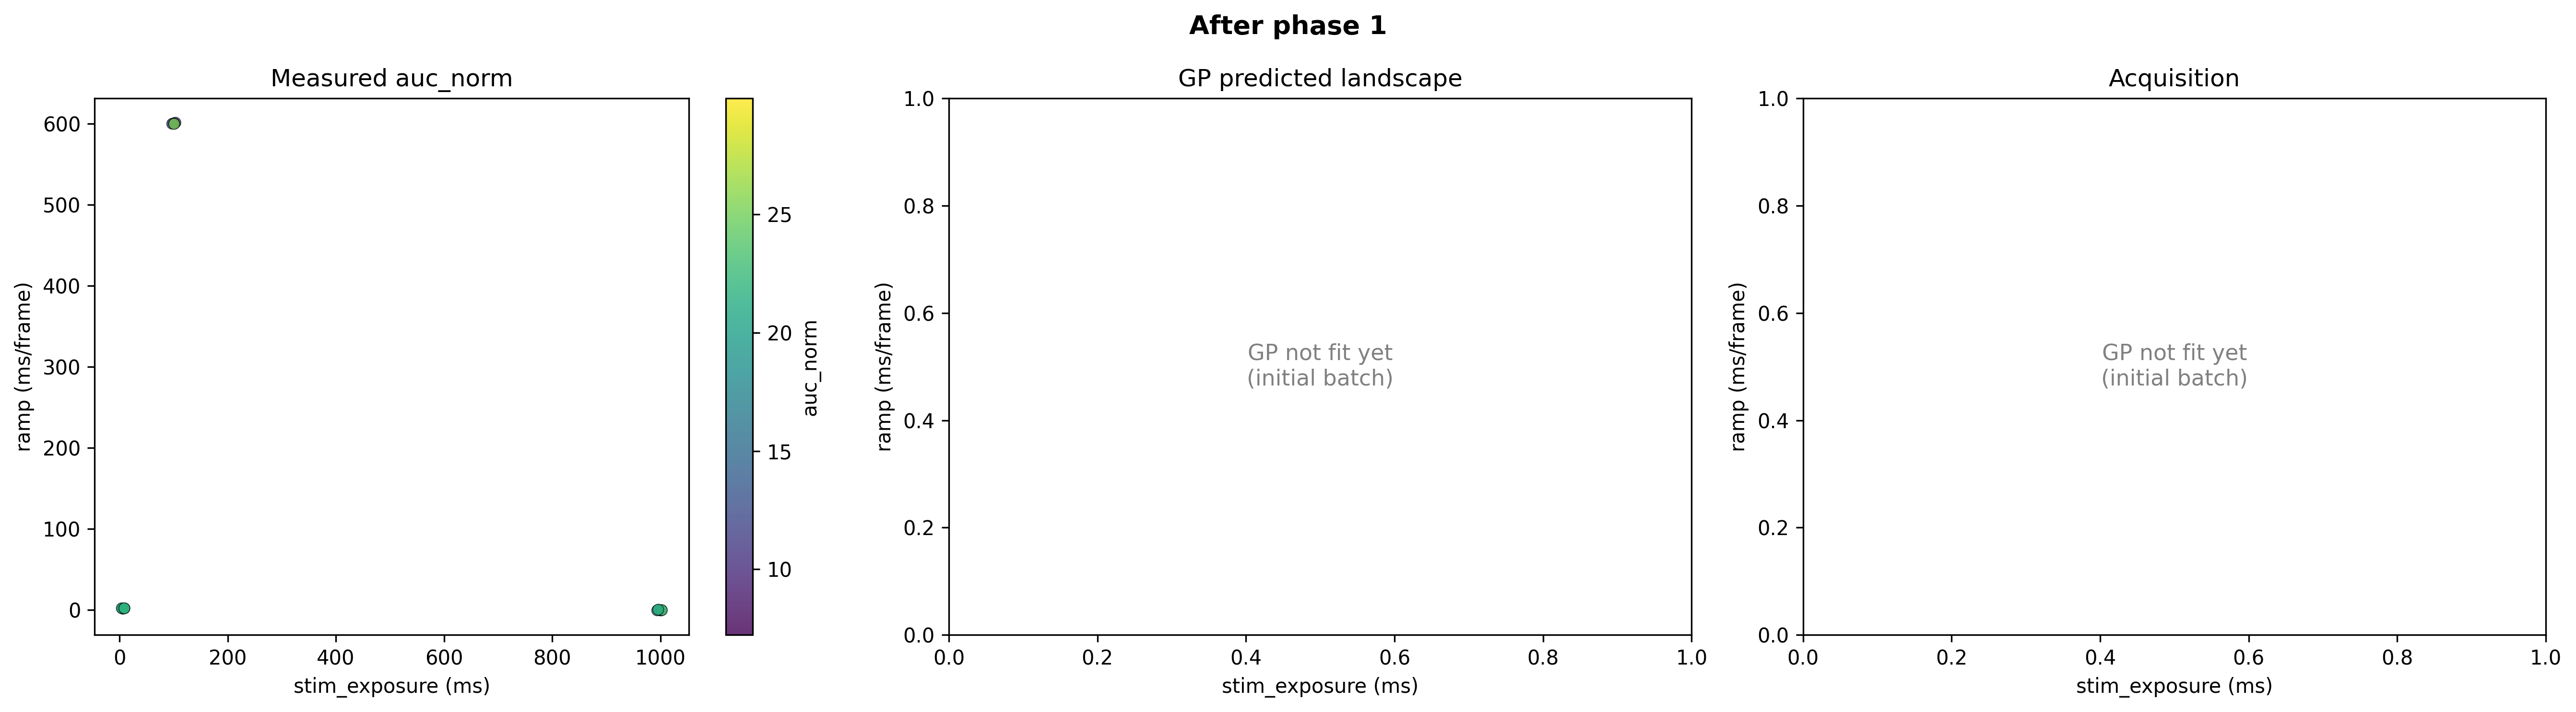


=== ComposedAgent: phase 2/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 1 — selected FOVs:
    A9_0000: 150 cells  cnr(mean=0.954, 53% below 0.95) (below min_cells)
    A9_0001: 46 cells  cnr(mean=0.944, 57% below 0.95) (below min_cells)
    A9_0002: 22 cells (below min_cells)
    A10_0000: 94 cells  cnr(mean=0.934, 51% below 0.95) (below min_cells)
    A10_0001: 45 cells  cnr(mean=0.865, 58% below 0.95) (below min_cells)
    A10_0002: 35 cells  cnr(mean=0.942, 41% below 0.95) (below min_cells)
    A11_0000: 44 cells  cnr(mean=0.779, 77% below 0.95)
    A11_0001: 172 cells  cnr(mean=0.808, 76% below 0.95)
    A11_0002: 220 cells  cnr(mean=0.833, 70% below 0.95) (below min_cells)
    A12_0000: 46 cells  cnr(mean=1.000, 21% below 0.95) (below min_cells)
    A12_0001: 19 cells (below min_cells)
    A12_0002: 19 cells (below min_cells)
    B12_0000: 71 cells  cnr(mean=0.978, 33% below 0.95) (below min_cells)
    B12_0001: 63 cells  cnr(mean=0.871, 62% below 0.95) (below min_cells)
    B12_0002: 54 cells  cnr(mean=0.948, 46% below 0.95) (

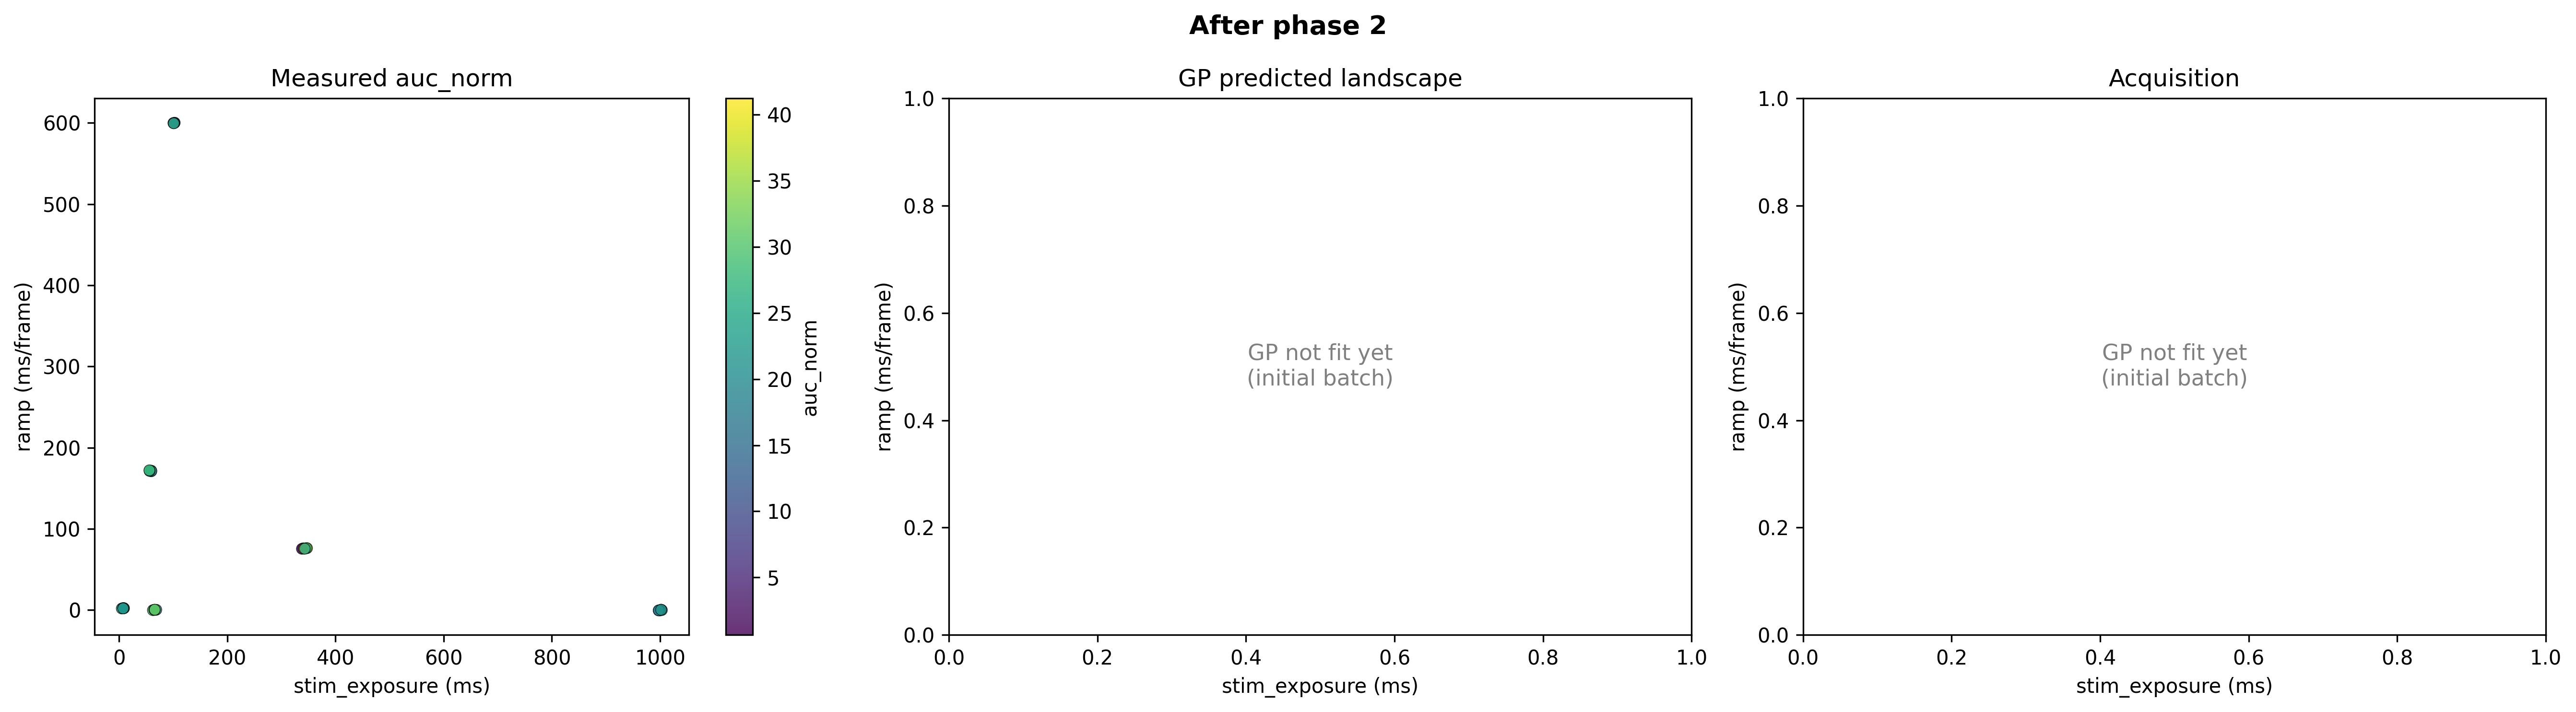


=== ComposedAgent: phase 3/13 ===
[FOVFinderAgent] Phase 2 — selected FOVs:
    B10_0000: 77 cells  cnr(mean=0.977, 40% below 0.95) (below min_cells)
    B10_0001: 77 cells  cnr(mean=0.892, 55% below 0.95) (below min_cells)
    B10_0002: 62 cells  cnr(mean=0.968, 42% below 0.95) (below min_cells)
    B9_0000: 100 cells  cnr(mean=0.965, 45% below 0.95) (below min_cells)
    B9_0001: 62 cells  cnr(mean=0.938, 47% below 0.95) (below min_cells)
    B9_0002: 59 cells  cnr(mean=0.999, 23% below 0.95) (below min_cells)
    B8_0000: 58 cells  cnr(mean=1.042, 19% below 0.95) (below min_cells)
    B8_0001: 48 cells  cnr(mean=1.071, 24% below 0.95) (below min_cells)
    B8_0002: 23 cells (below min_cells)
    B7_0000: 39 cells  cnr(mean=1.061, 24% below 0.95) (below min_cells)
    B7_0001: 31 cells (below min_cells)
    B7_0002: 29 cells (below min_cells)
    B6_0000: 69 cells  cnr(mean=0.979, 39% below 0.95) (below min_cells)
    B6_0001: 60 cells  cnr(mean=0.972, 46% below 0.95) (below min_cel

sample: 100%|##########| 1200/1200 [00:02<00:00, 400.72it/s, 7 steps of size 5.38e-01. acc. prob=0.88] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      3.23      3.60      2.29      0.09      6.70    759.22      1.00
k_length[1]      2.75      2.50      2.04      0.12      5.14    754.62      1.00
k_length[2]      2.17      2.41      1.38      0.07      4.73    622.20      1.00
k_length[3]      1.23      0.95      1.04      0.11      2.24    500.93      1.00
k_length[4]      1.08      0.97      0.83      0.22      2.02    463.33      1.00
    k_scale      0.81      0.42      0.76      0.21      1.40    701.21      1.00
      noise      0.46      0.26      0.40      0.08      0.82    504.23      1.00

Computing robust acquisition over 3424 scenarios (214 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.080863
  Robust acq stats: min=0.165303, max=0.299782
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 213 grid points x 16 covariate samples
  bes

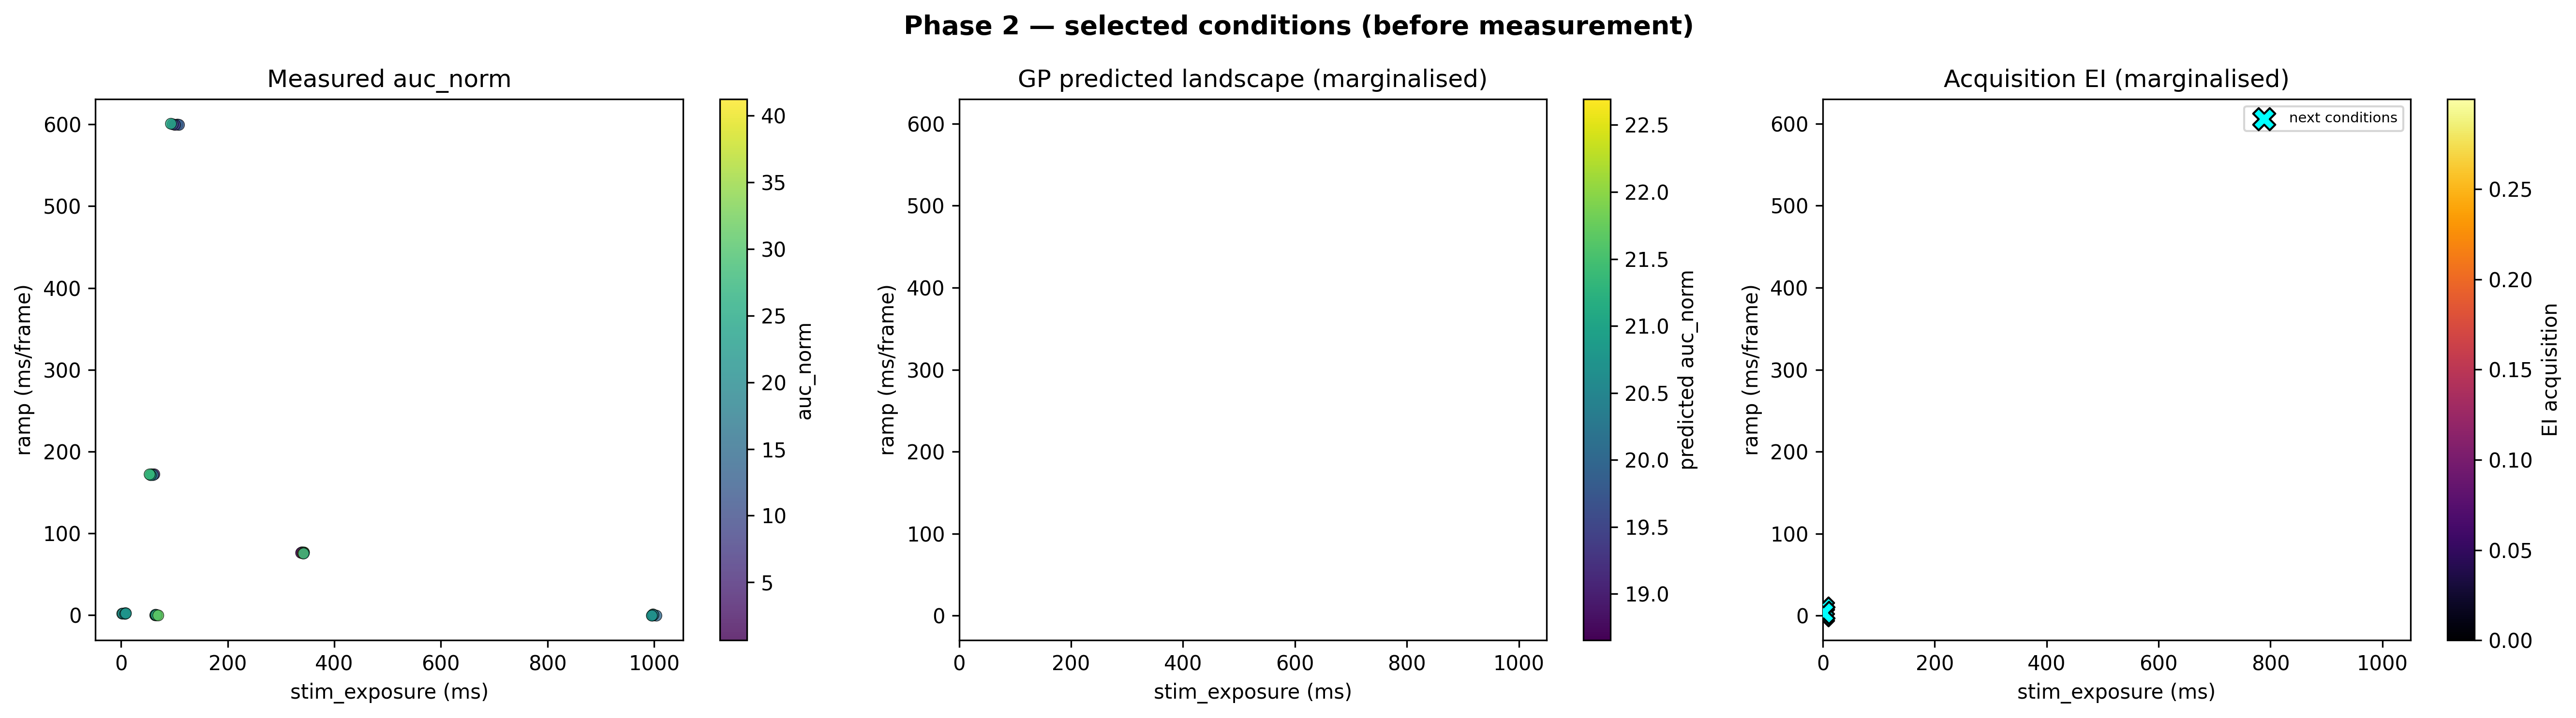

    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.30, pulse_interval=1: n_pulses=60 -> base=46.7ms, ramp=0.68ms/pulse, peak=86.7ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.00, pulse_interval=9: n_pulses=7 -> base=571.4ms, ramp=0.00ms/pulse, peak=571.4ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.60, pulse_interval=4: n_pulses=15 -> base=106.7ms, ramp=22.86ms/pulse, peak=426.7ms
  Created 1620 events for phase 2
    Cond 0 (FOVs 36-41): stim_exposure=47ms, ramp=1ms/frame, pulse_interval=1min, n_pulses=60 (final exposure: 87ms)
    Cond 1 (FOVs 42-47): stim_exposure=571ms, ramp=0ms/frame, pulse_interval=9min, n_pulses=7 (final exposure: 571ms)
    Cond 2 (FOVs 48-53): stim_exposure=107ms, ramp=23ms/frame, pulse_interval=4min, n_pulses=15 (final exposure: 427ms)
  Phase 2: 17 FOVs, mean auc_norm=18.4949, max=30.6902


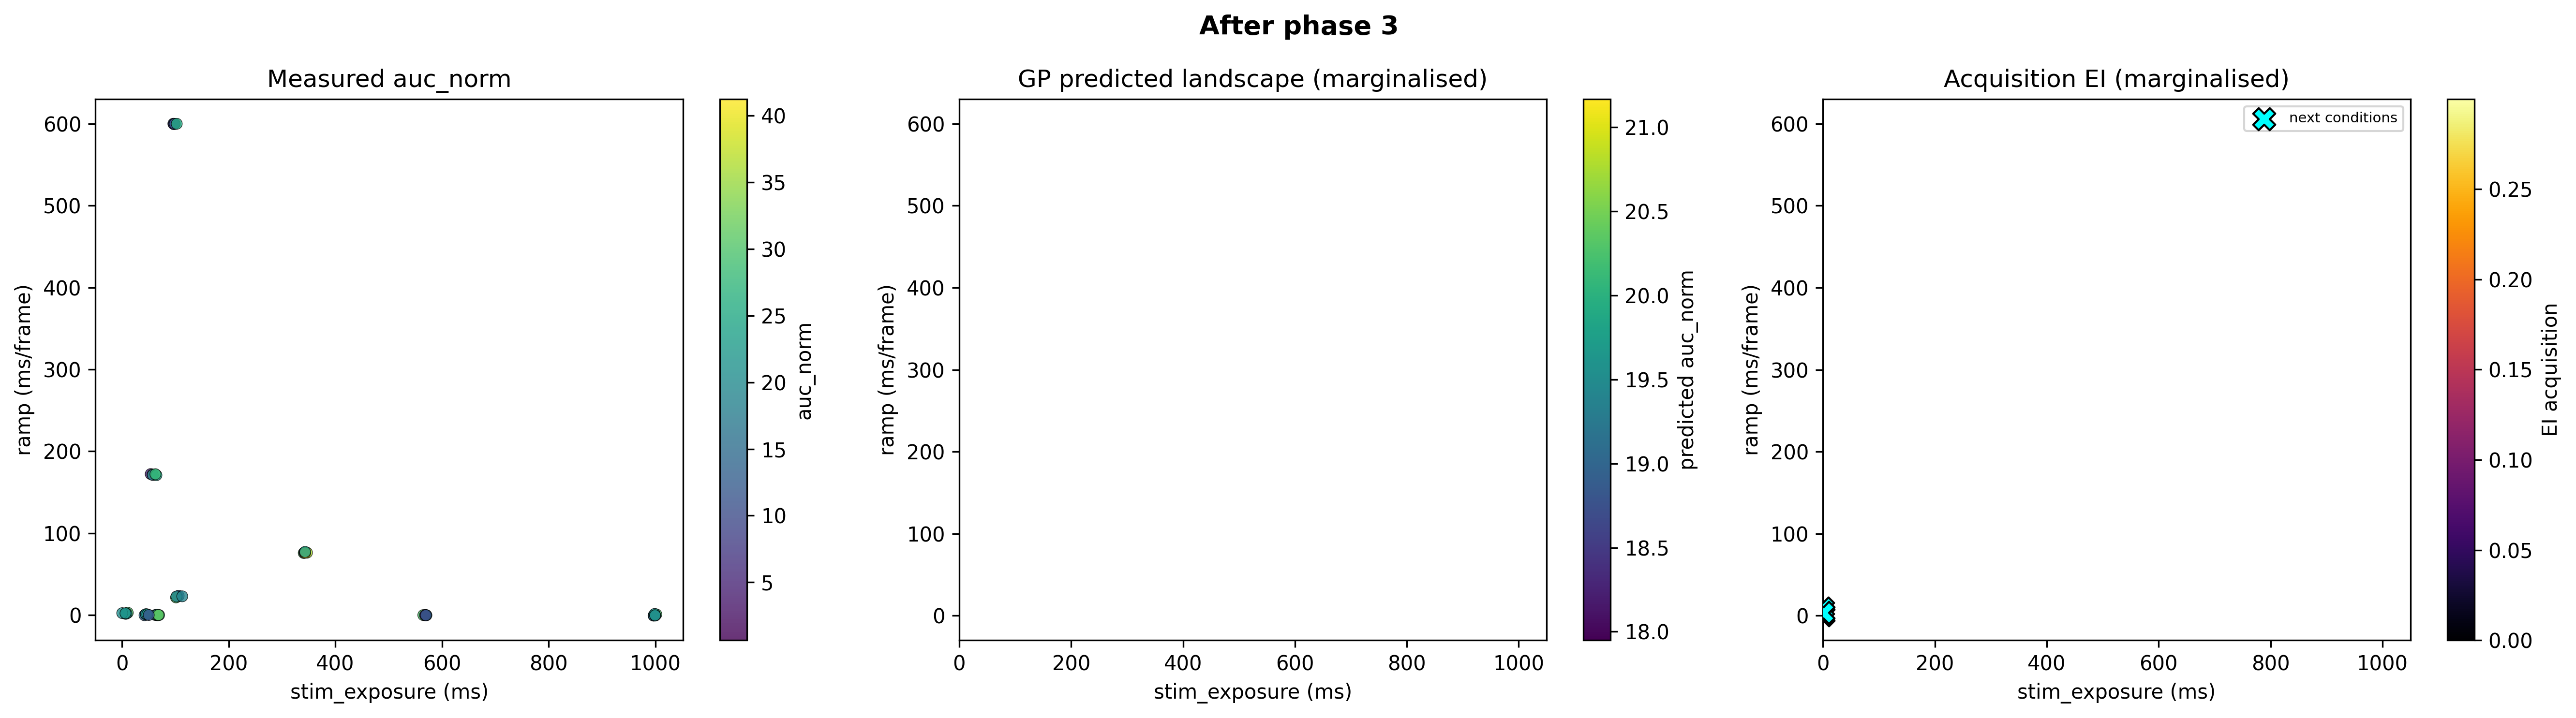


=== ComposedAgent: phase 4/13 ===
[FOVFinderAgent] Phase 3 — selected FOVs:
    B4_0000: 186 cells  cnr(mean=0.859, 63% below 0.95) (below min_cells)
    B4_0001: 116 cells  cnr(mean=0.996, 36% below 0.95) (below min_cells)
    B4_0002: 88 cells  cnr(mean=1.000, 39% below 0.95) (below min_cells)
    B3_0000: 145 cells  cnr(mean=0.994, 35% below 0.95) (below min_cells)
    B3_0001: 102 cells  cnr(mean=1.009, 33% below 0.95) (below min_cells)
    B3_0002: 67 cells  cnr(mean=1.030, 33% below 0.95) (below min_cells)
    B2_0000: 125 cells  cnr(mean=0.975, 42% below 0.95) (below min_cells)
    B2_0001: 118 cells  cnr(mean=0.937, 52% below 0.95) (below min_cells)
    B2_0002: 99 cells  cnr(mean=0.939, 43% below 0.95) (below min_cells)
    C2_0000: 16 cells (below min_cells)
    C2_0001: 16 cells (below min_cells)
    C2_0002: 14 cells (below min_cells)
    C3_0000: 66 cells  cnr(mean=1.050, 28% below 0.95) (below min_cells)
    C3_0001: 37 cells  cnr(mean=0.993, 36% below 0.95) (below min_c

sample: 100%|##########| 1200/1200 [00:03<00:00, 332.60it/s, 7 steps of size 4.94e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.46      2.69      1.67      0.04      4.98    897.03      1.00
k_length[1]      2.12      2.28      1.46      0.07      4.33    801.23      1.00
k_length[2]      1.94      2.15      1.21      0.05      4.21    674.51      1.00
k_length[3]      2.12      2.91      1.40      0.12      4.10    525.19      1.00
k_length[4]      1.02      1.05      0.72      0.06      2.04    901.92      1.00
    k_scale      0.52      0.31      0.46      0.12      0.95    769.38      1.00
      noise      0.68      0.24      0.68      0.27      1.05    532.46      1.00

Computing robust acquisition over 3376 scenarios (211 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.269024
  Robust acq stats: min=0.104517, max=0.202563
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 210 grid points x 16 covariate samples
  bes

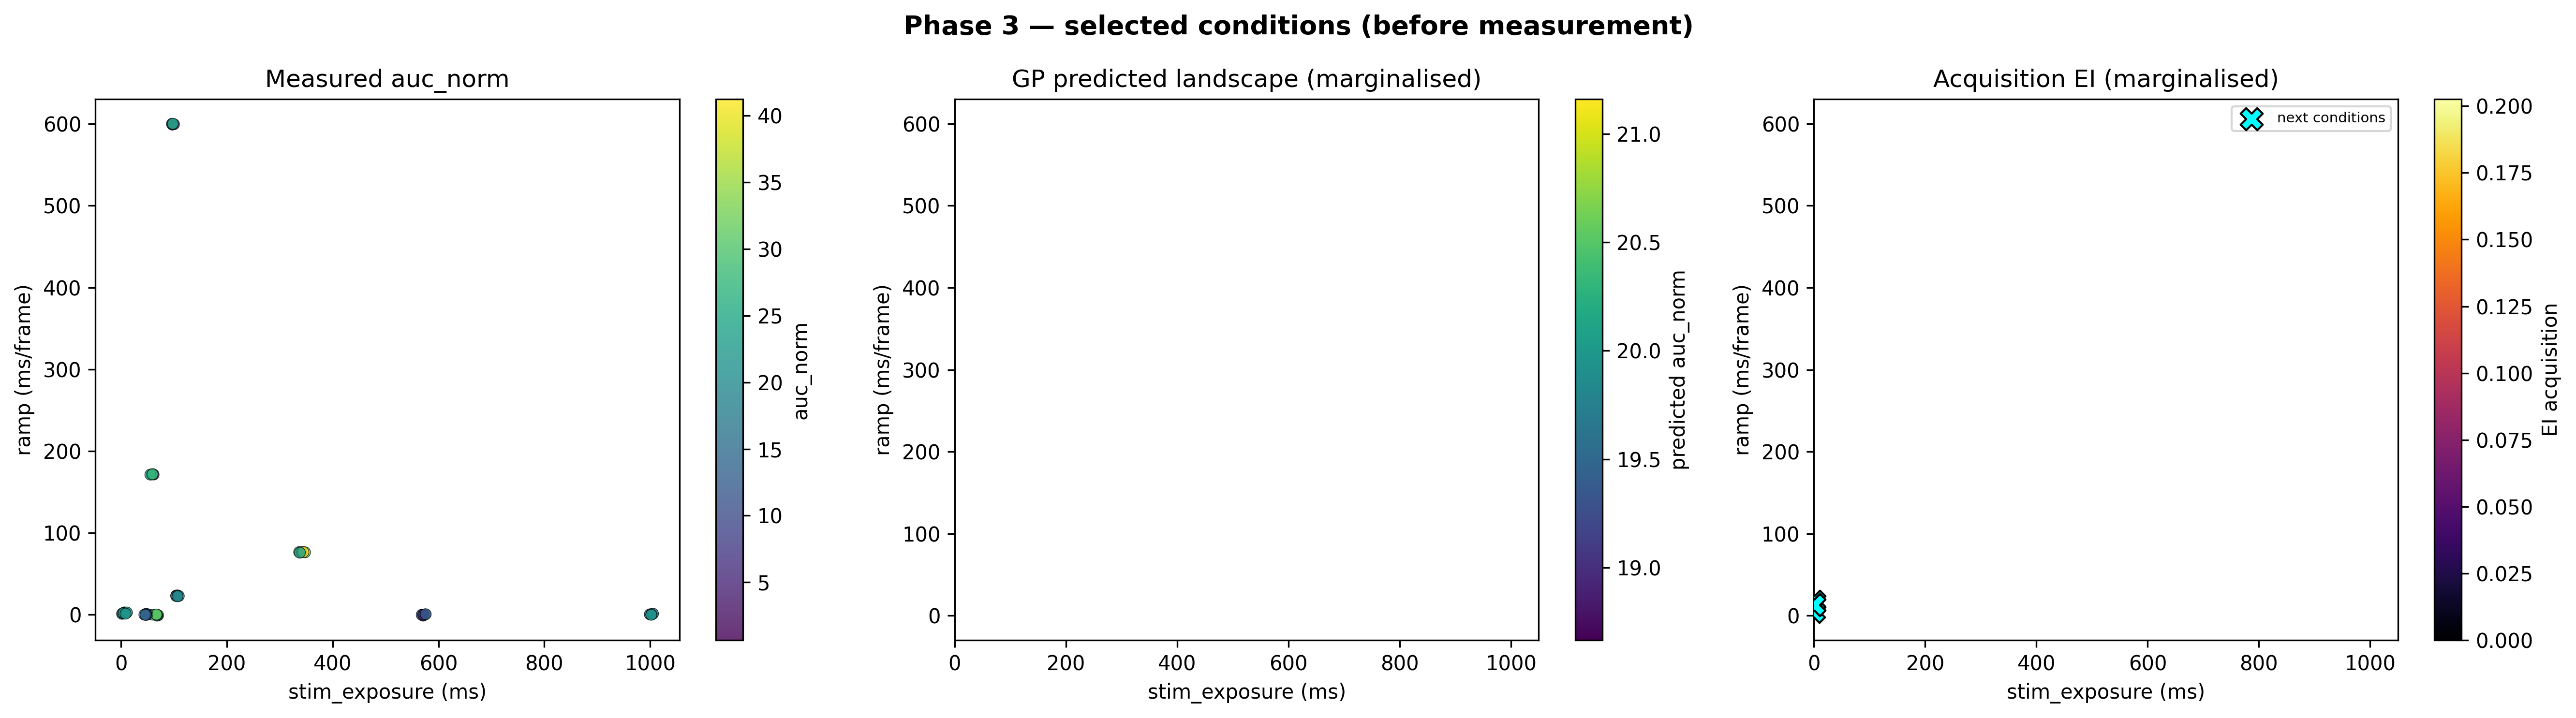

    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.00, pulse_interval=5: n_pulses=12 -> base=333.3ms, ramp=0.00ms/pulse, peak=333.3ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.40, pulse_interval=17: n_pulses=4 -> base=600.0ms, ramp=266.67ms/pulse, peak=1400.0ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.20, pulse_interval=13: n_pulses=5 -> base=640.0ms, ramp=80.00ms/pulse, peak=960.0ms
  Created 1620 events for phase 3
    Cond 0 (FOVs 54-59): stim_exposure=333ms, ramp=0ms/frame, pulse_interval=5min, n_pulses=12 (final exposure: 333ms)
    Cond 1 (FOVs 60-65): stim_exposure=600ms, ramp=267ms/frame, pulse_interval=17min, n_pulses=4 (final exposure: 1400ms)
    Cond 2 (FOVs 66-71): stim_exposure=640ms, ramp=80ms/frame, pulse_interval=13min, n_pulses=5 (final exposure: 960ms)
  Phase 3: 17 FOVs, mean auc_norm=17.1035, max=30.8871


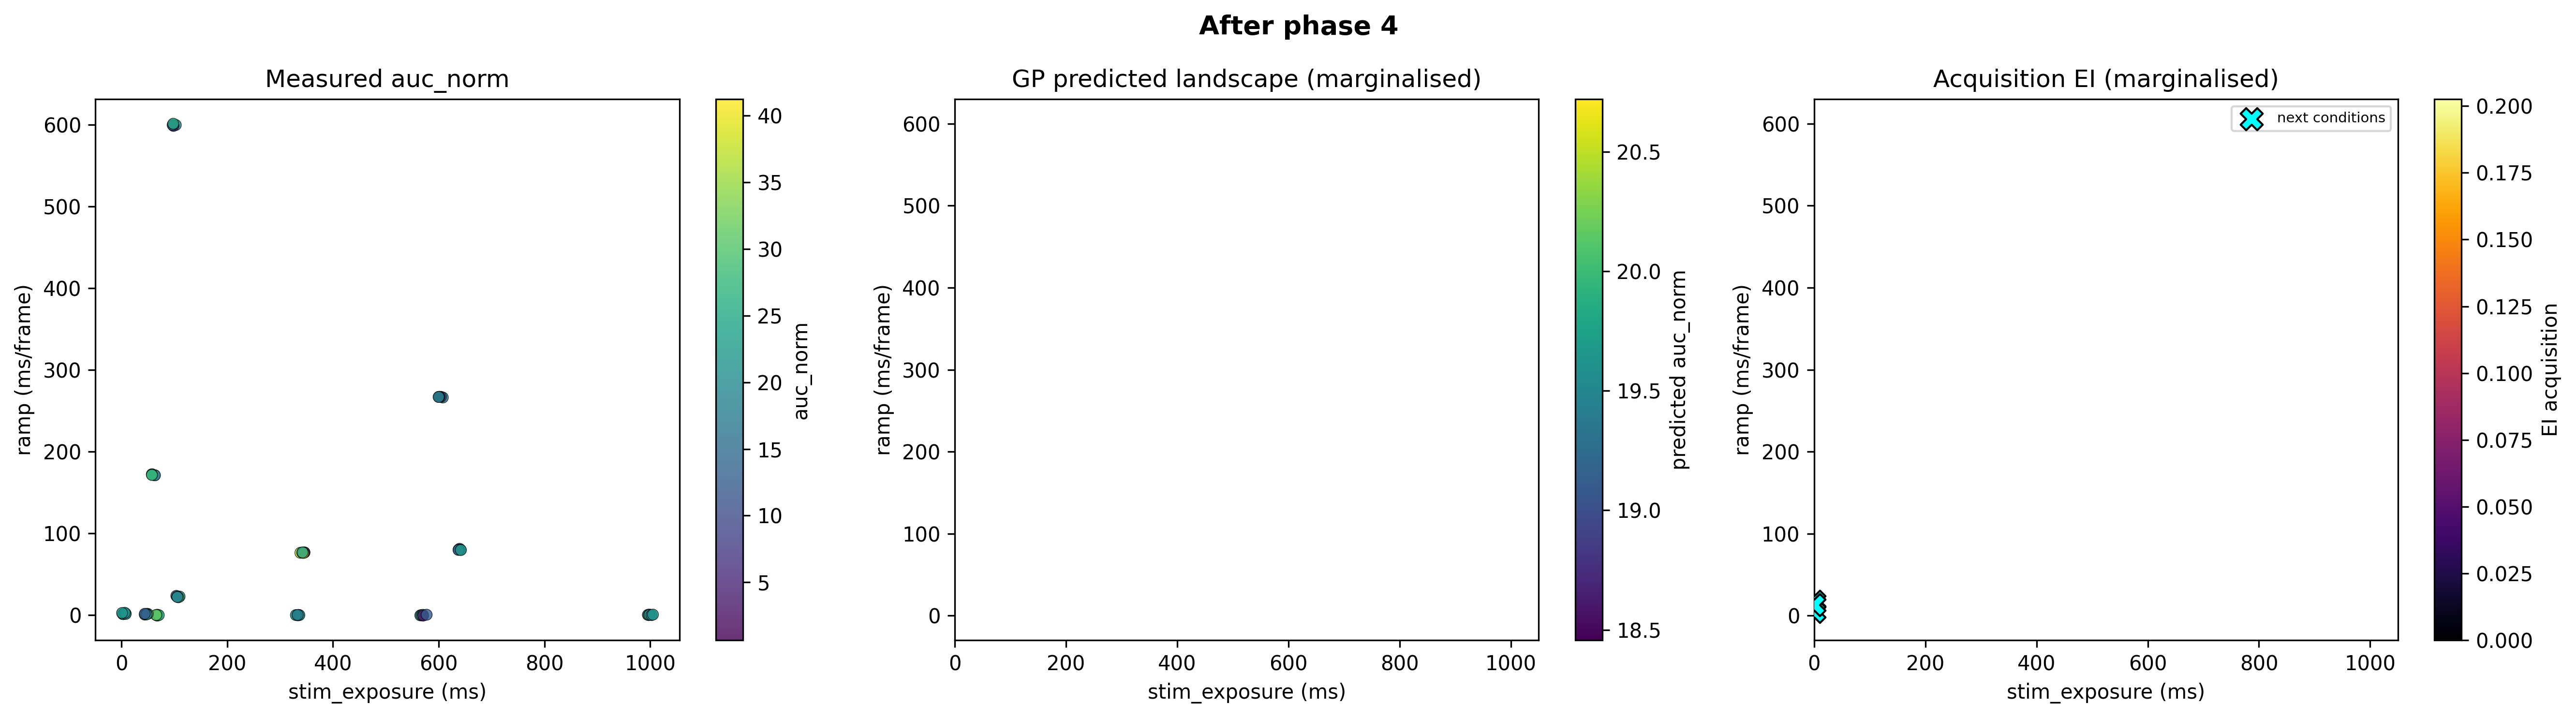


=== ComposedAgent: phase 5/13 ===
[FOVFinderAgent] Phase 4 — selected FOVs:
    C5_0000: 114 cells  cnr(mean=0.948, 50% below 0.95) (below min_cells)
    C5_0001: 101 cells  cnr(mean=0.866, 63% below 0.95) (below min_cells)
    C5_0002: 90 cells  cnr(mean=0.966, 43% below 0.95) (below min_cells)
    C6_0000: 143 cells  cnr(mean=0.839, 68% below 0.95) (below min_cells)
    C6_0001: 84 cells  cnr(mean=0.956, 48% below 0.95) (below min_cells)
    C6_0002: 82 cells  cnr(mean=0.901, 51% below 0.95) (below min_cells)
    C7_0000: 151 cells  cnr(mean=0.883, 60% below 0.95) (below min_cells)
    C7_0001: 108 cells  cnr(mean=0.910, 58% below 0.95) (below min_cells)
    C7_0002: 104 cells  cnr(mean=0.830, 62% below 0.95) (below min_cells)
    C8_0000: 132 cells  cnr(mean=0.879, 56% below 0.95) (below min_cells)
    C8_0001: 75 cells  cnr(mean=0.901, 55% below 0.95) (below min_cells)
    C8_0002: 46 cells  cnr(mean=0.927, 50% below 0.95) (below min_cells)
    C9_0000: 81 cells  cnr(mean=0.916, 5

sample: 100%|##########| 1200/1200 [00:04<00:00, 274.70it/s, 7 steps of size 4.75e-01. acc. prob=0.92] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      3.33      3.46      2.53      0.27      6.30    590.50      1.00
k_length[1]      1.57      1.02      1.35      0.27      2.76    921.24      1.00
k_length[2]      3.40      2.73      2.61      0.13      7.05    797.04      1.00
k_length[3]      2.05      1.56      1.62      0.23      3.91    701.24      1.00
k_length[4]      1.52      0.94      1.36      0.26      2.81   1031.85      1.00
    k_scale      0.65      0.37      0.58      0.17      1.09    834.95      1.00
      noise      0.60      0.16      0.58      0.36      0.86    626.07      1.00

Computing robust acquisition over 3328 scenarios (208 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.389384
  Robust acq stats: min=0.055063, max=0.236313
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 207 grid points x 16 covariate samples
  bes

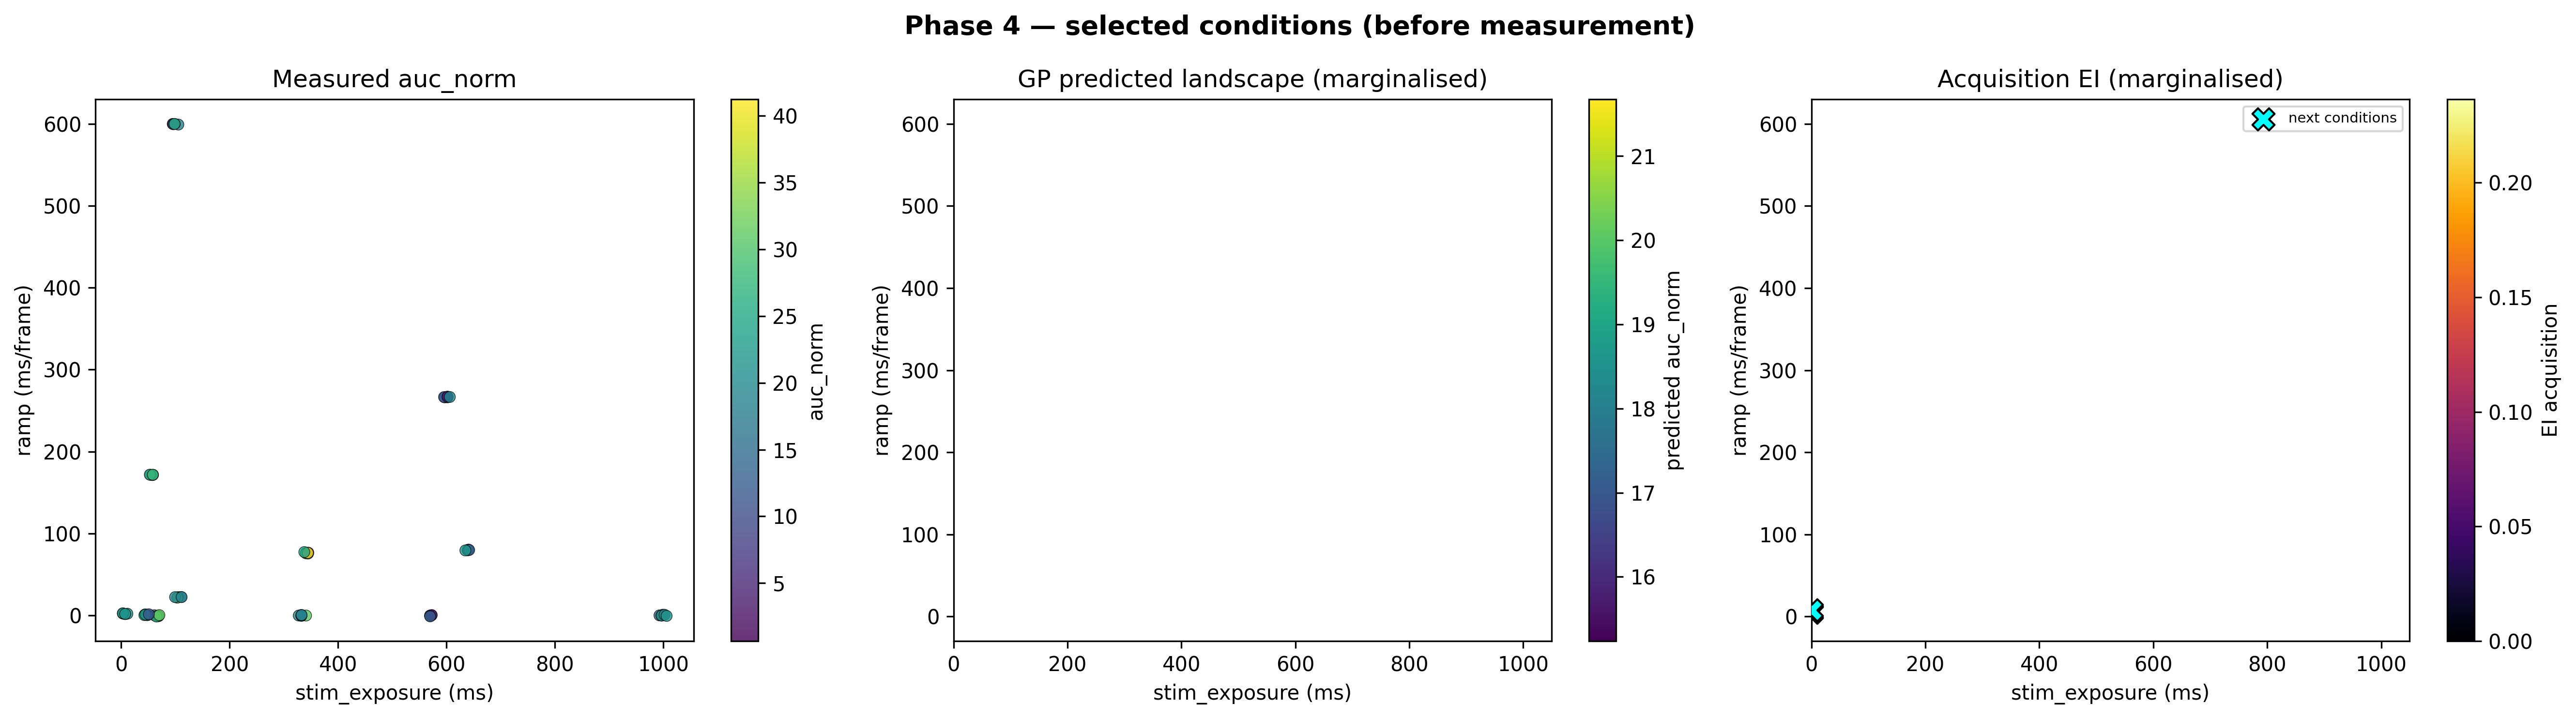

    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.00, pulse_interval=6: n_pulses=10 -> base=400.0ms, ramp=0.00ms/pulse, peak=400.0ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.30, pulse_interval=5: n_pulses=12 -> base=233.3ms, ramp=18.18ms/pulse, peak=433.3ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.20, pulse_interval=8: n_pulses=8 -> base=400.0ms, ramp=28.57ms/pulse, peak=600.0ms
  Created 1620 events for phase 4
    Cond 0 (FOVs 72-77): stim_exposure=400ms, ramp=0ms/frame, pulse_interval=6min, n_pulses=10 (final exposure: 400ms)
    Cond 1 (FOVs 78-83): stim_exposure=233ms, ramp=18ms/frame, pulse_interval=5min, n_pulses=12 (final exposure: 433ms)
    Cond 2 (FOVs 84-89): stim_exposure=400ms, ramp=29ms/frame, pulse_interval=8min, n_pulses=8 (final exposure: 600ms)
  Phase 4: 17 FOVs, mean auc_norm=22.3478, max=45.8218


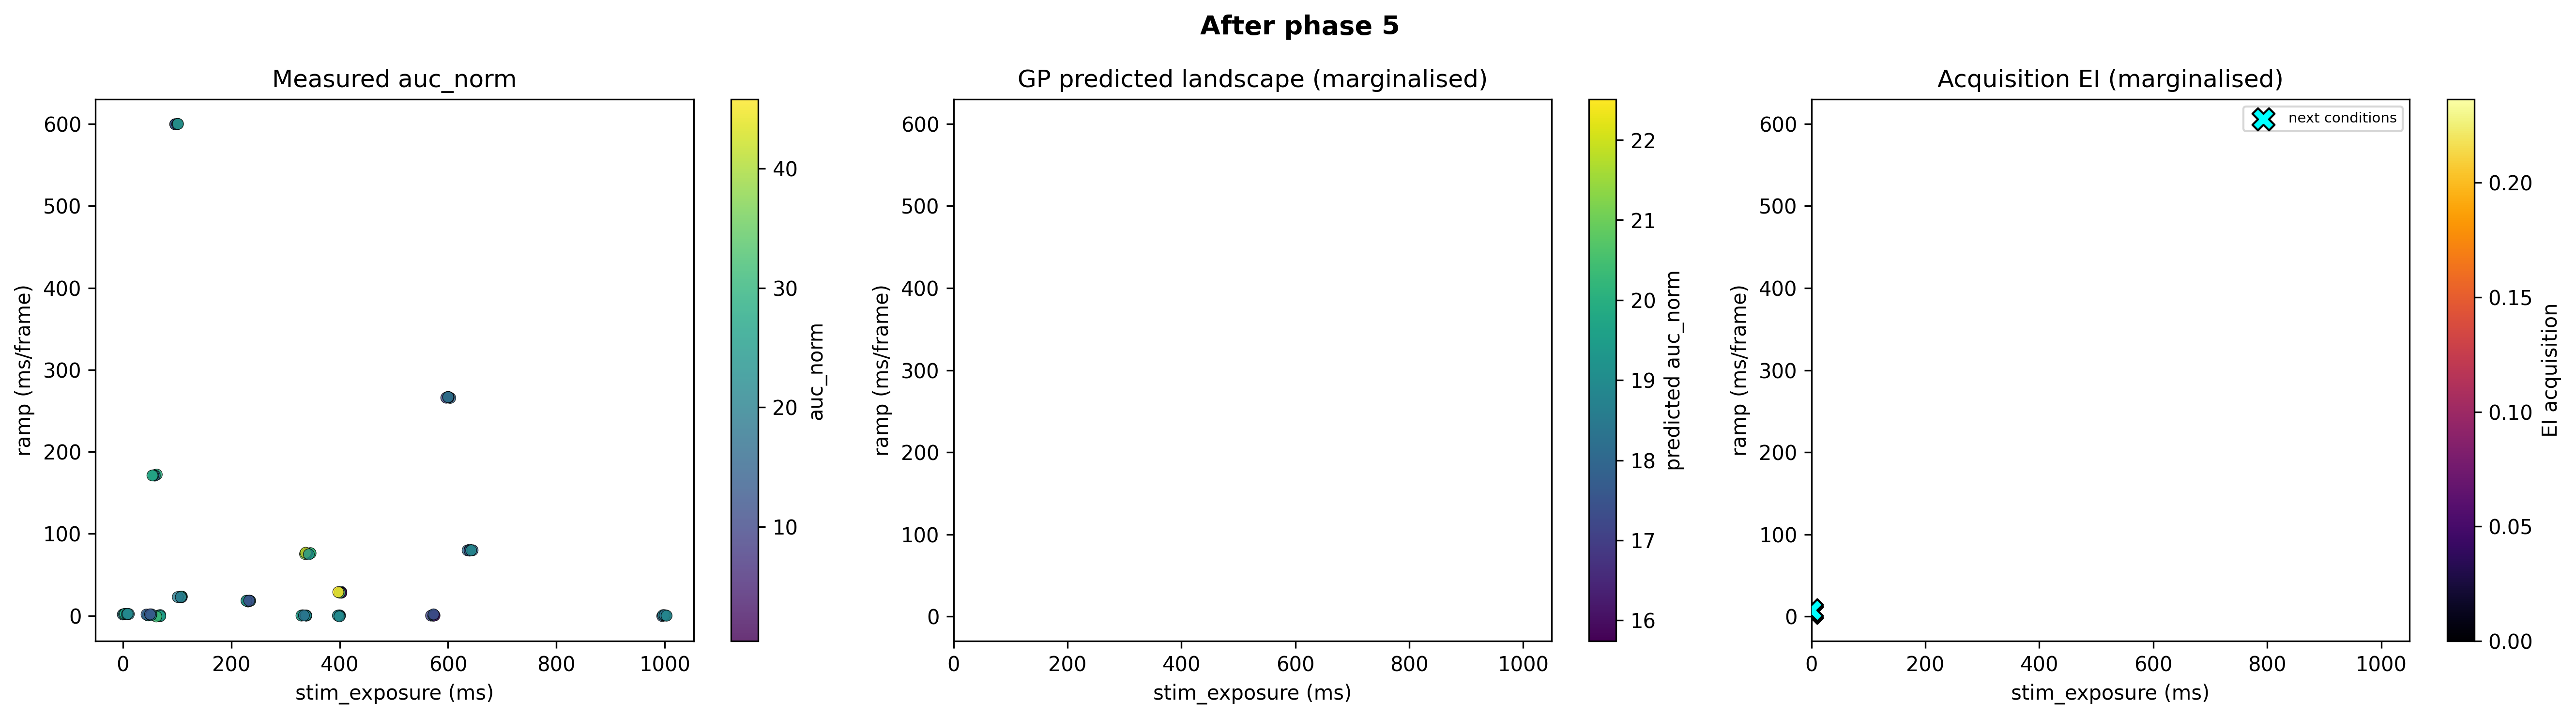


=== ComposedAgent: phase 6/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 5 — selected FOVs:
    C11_0000: 54 cells  cnr(mean=0.729, 81% below 0.95)
    C11_0001: 57 cells  cnr(mean=0.919, 54% below 0.95) (below min_cells)
    C11_0002: 42 cells  cnr(mean=0.859, 62% below 0.95) (below min_cells)
    C12_0000: 152 cells  cnr(mean=0.904, 54% below 0.95) (below min_cells)
    C12_0001: 58 cells  cnr(mean=0.949, 38% below 0.95) (below min_cells)
    C12_0002: 42 cells  cnr(mean=1.125, 19% below 0.95) (below min_cells)
    D12_0000: 69 cells  cnr(mean=0.990, 39% below 0.95) (below min_cells)
    D12_0001: 42 cells  cnr(mean=1.071, 15% below 0.95) (below min_cells)
    D12_0002: 30 cells (below min_cells)
    D11_0000: 184 cells  cnr(mean=0.776, 81% below 0.95)
    D11_0001: 78 cells  cnr(mean=0.868, 65% below 0.95) (below min_cells)
    D11_0002: 71 cells  cnr(mean=0.869, 59% below 0.95) (below min_cells)
    D10_0000: 110 cells  cnr(mean=0.868, 61% below 0.95) (below min_cells)
    D10_0001: 107 cells  cnr(mean=0.886, 63% below 0.95) (belo

sample: 100%|##########| 1200/1200 [00:04<00:00, 254.86it/s, 7 steps of size 6.52e-01. acc. prob=0.86]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      4.07      3.98      3.04      0.47      7.25    476.61      1.00
k_length[1]      2.12      1.44      1.75      0.45      3.93    814.21      1.00
k_length[2]      4.66      3.63      3.53      0.64      8.74    703.95      1.01
k_length[3]      2.81      1.62      2.45      0.68      4.83    676.14      1.00
k_length[4]      1.51      0.84      1.33      0.34      2.65    857.21      1.00
    k_scale      0.79      0.46      0.69      0.27      1.35    823.23      1.00
      noise      0.55      0.11      0.54      0.37      0.73    855.10      1.00

Computing robust acquisition over 3280 scenarios (205 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.202673
  Robust acq stats: min=0.048365, max=0.181064
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 204 grid points x 16 covariate samples
  bes

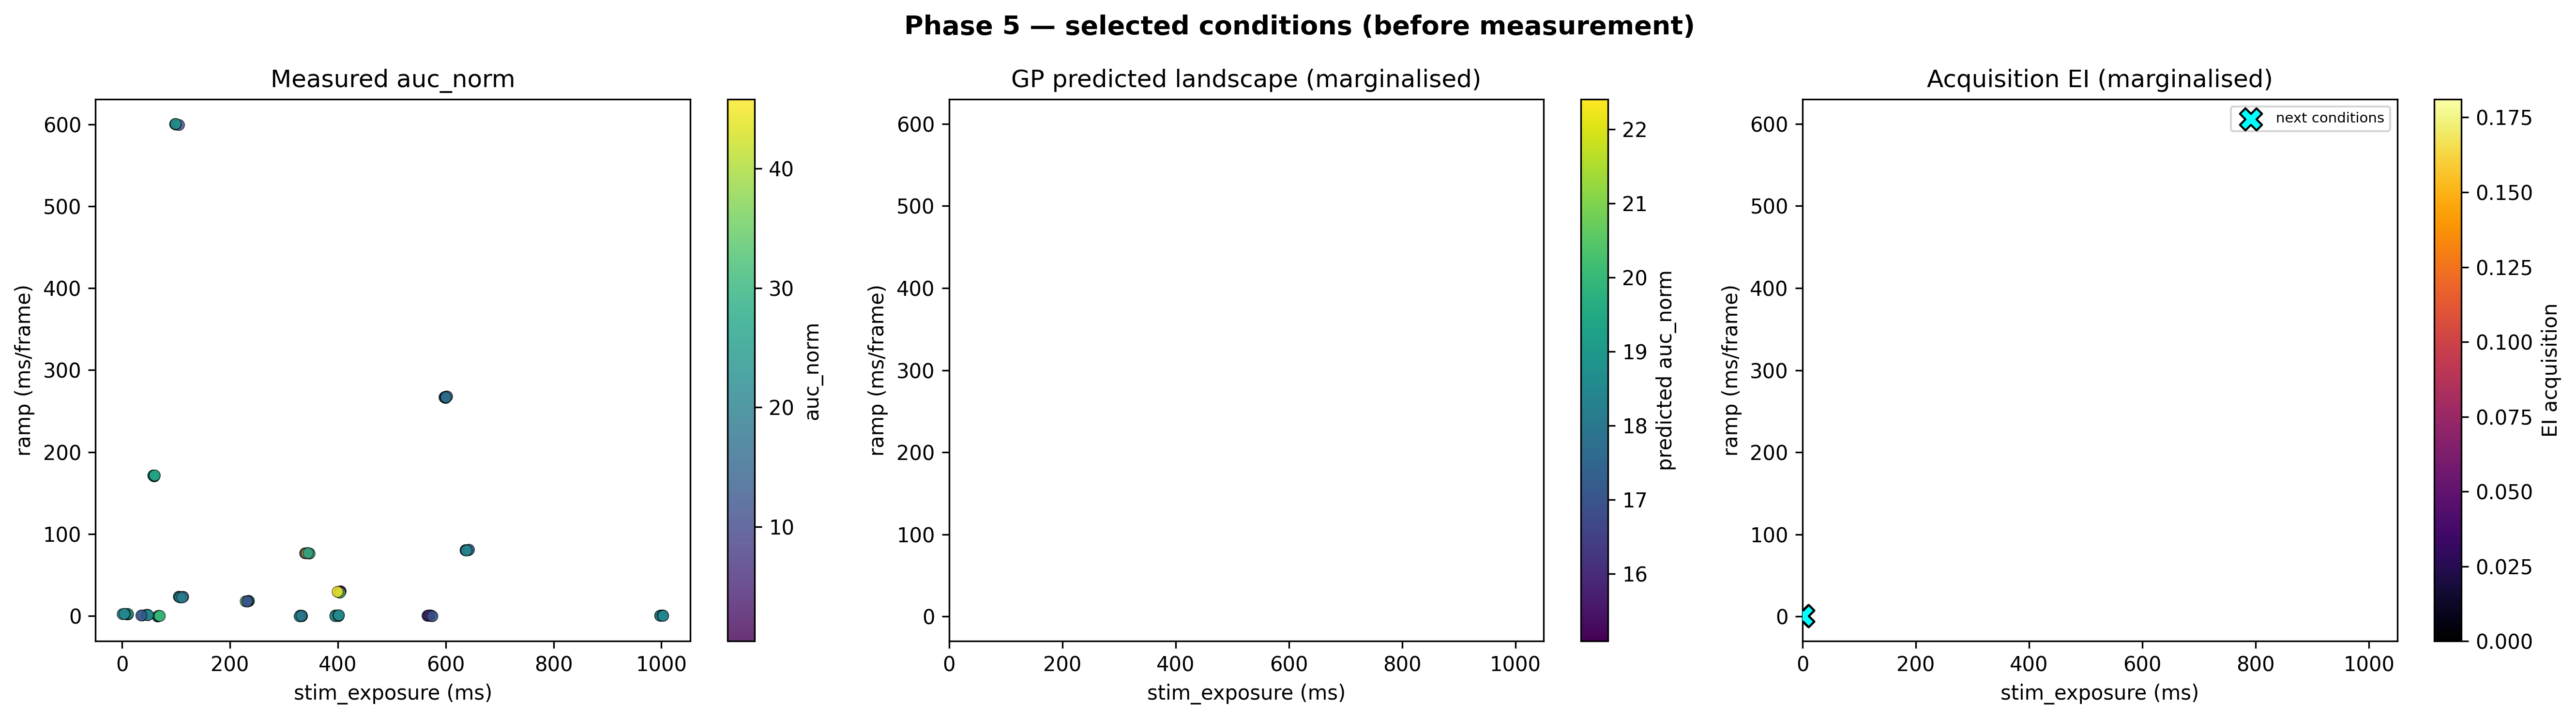

    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.10, pulse_interval=1: n_pulses=60 -> base=60.0ms, ramp=0.23ms/pulse, peak=73.3ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.50, pulse_interval=1: n_pulses=60 -> base=33.3ms, ramp=1.13ms/pulse, peak=100.0ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.70, pulse_interval=1: n_pulses=60 -> base=20.0ms, ramp=1.58ms/pulse, peak=113.3ms
  Cond 2: dropped 4/60 sub-25ms pulses (min computed exposure was 20.000 ms)
  Created 1620 events for phase 5
    Cond 0 (FOVs 90-95): stim_exposure=60ms, ramp=0ms/frame, pulse_interval=1min, n_pulses=60 (final exposure: 73ms)
    Cond 1 (FOVs 96-101): stim_exposure=33ms, ramp=1ms/frame, pulse_interval=1min, n_pulses=60 (final exposure: 100ms)
    Cond 2 (FOVs 102-107): stim_exposure=20ms, ramp=2ms/frame, pulse_interval=1min, n_pulses=60 (final exposure: 113ms)
  Phase 5: 17 FOVs, mean auc_norm=16.2886, max=31.3330


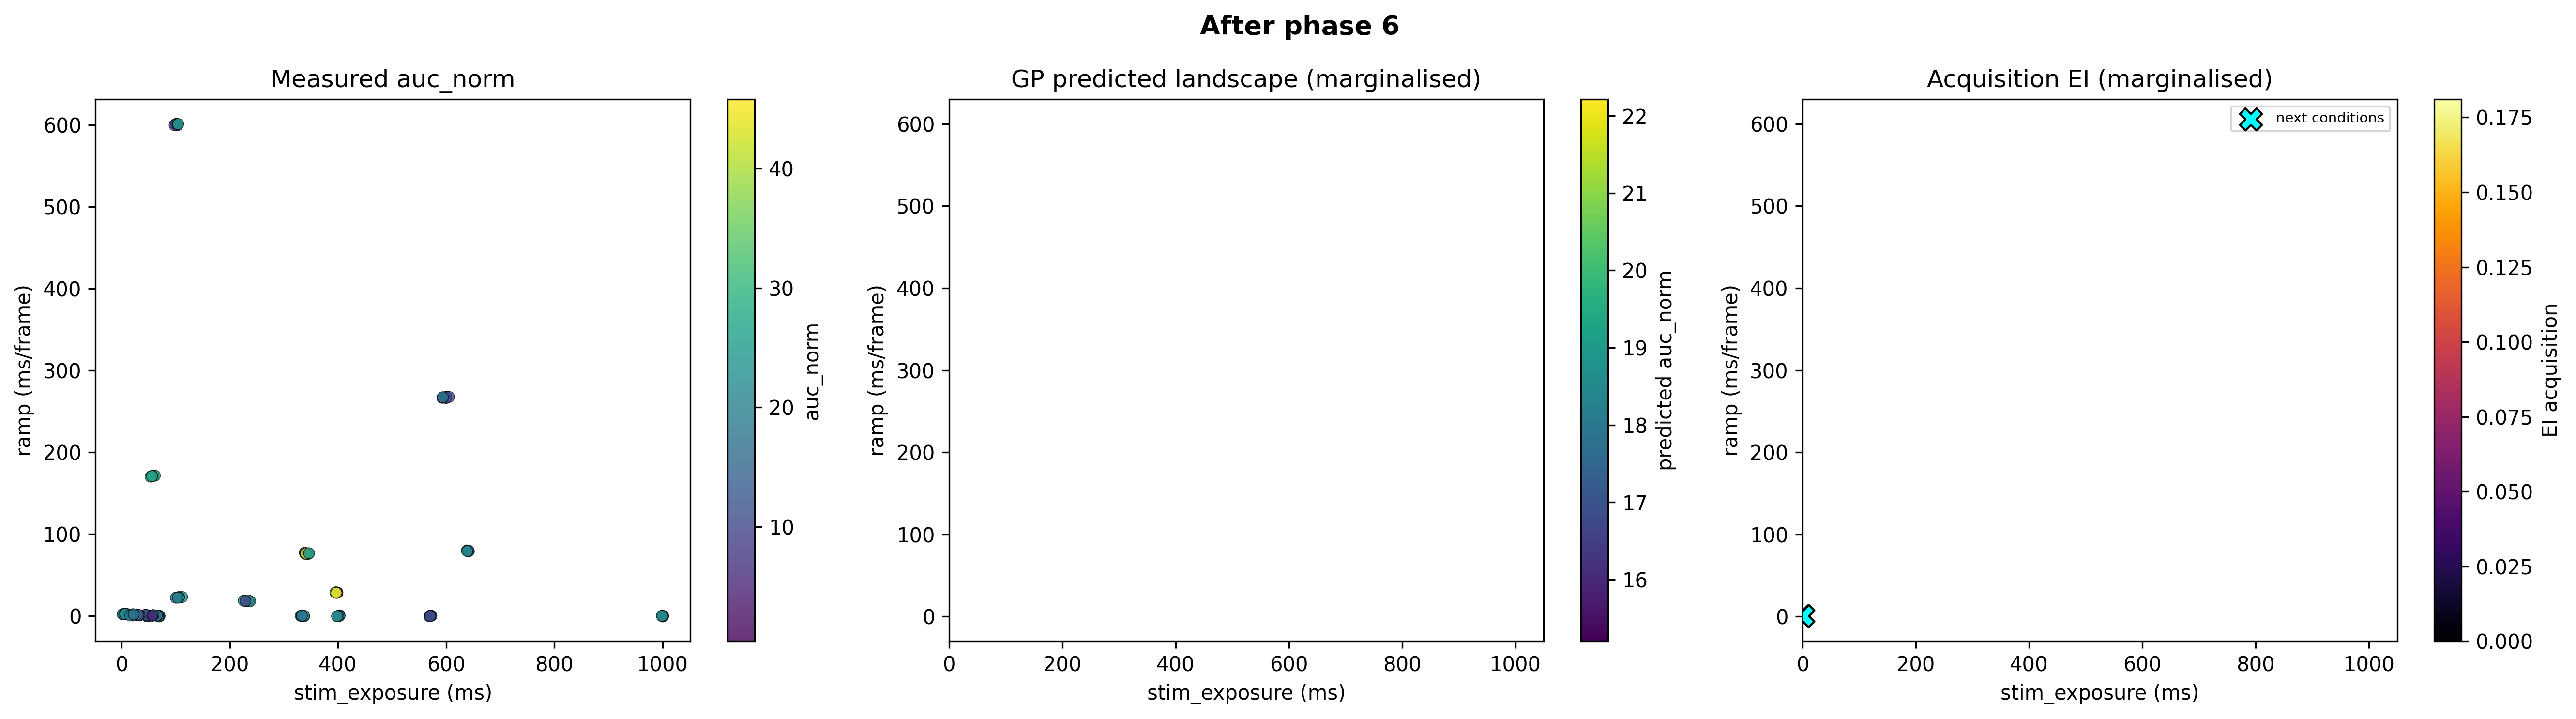


=== ComposedAgent: phase 7/13 ===
[FOVFinderAgent] Phase 6 — selected FOVs:
    D8_0000: 77 cells  cnr(mean=0.839, 67% below 0.95) (below min_cells)
    D8_0001: 60 cells  cnr(mean=0.976, 42% below 0.95) (below min_cells)
    D8_0002: 56 cells  cnr(mean=0.885, 62% below 0.95) (below min_cells)
    D7_0000: 76 cells  cnr(mean=0.771, 83% below 0.95)
    D7_0001: 86 cells  cnr(mean=0.809, 72% below 0.95) (below min_cells)
    D7_0002: 65 cells  cnr(mean=0.843, 66% below 0.95) (below min_cells)
    D6_0000: 145 cells  cnr(mean=0.786, 76% below 0.95)
    D6_0001: 86 cells  cnr(mean=0.924, 60% below 0.95) (below min_cells)
    D6_0002: 63 cells  cnr(mean=0.949, 53% below 0.95) (below min_cells)
    D5_0000: 127 cells  cnr(mean=0.875, 63% below 0.95) (below min_cells)
    D5_0001: 84 cells  cnr(mean=0.928, 47% below 0.95) (below min_cells)
    D5_0002: 76 cells  cnr(mean=0.868, 65% below 0.95) (below min_cells)
    D4_0000: 135 cells  cnr(mean=0.763, 77% below 0.95)
    D4_0001: 143 cells  c

sample: 100%|##########| 1200/1200 [00:06<00:00, 194.57it/s, 7 steps of size 5.27e-01. acc. prob=0.91] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      3.88      4.07      3.02      0.51      7.37    675.12      1.00
k_length[1]      1.31      0.81      1.15      0.26      2.25    852.92      1.00
k_length[2]      4.96      3.81      3.79      0.84      9.12    615.70      1.00
k_length[3]      2.33      1.30      2.06      0.64      3.88    579.12      1.00
k_length[4]      1.47      0.72      1.31      0.47      2.46    955.58      1.00
    k_scale      0.89      0.51      0.77      0.29      1.48    553.16      1.00
      noise      0.54      0.11      0.53      0.36      0.68    950.61      1.00

Computing robust acquisition over 3232 scenarios (202 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.396971
  Robust acq stats: min=0.032640, max=0.156349
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 201 grid points x 16 covariate samples
  bes

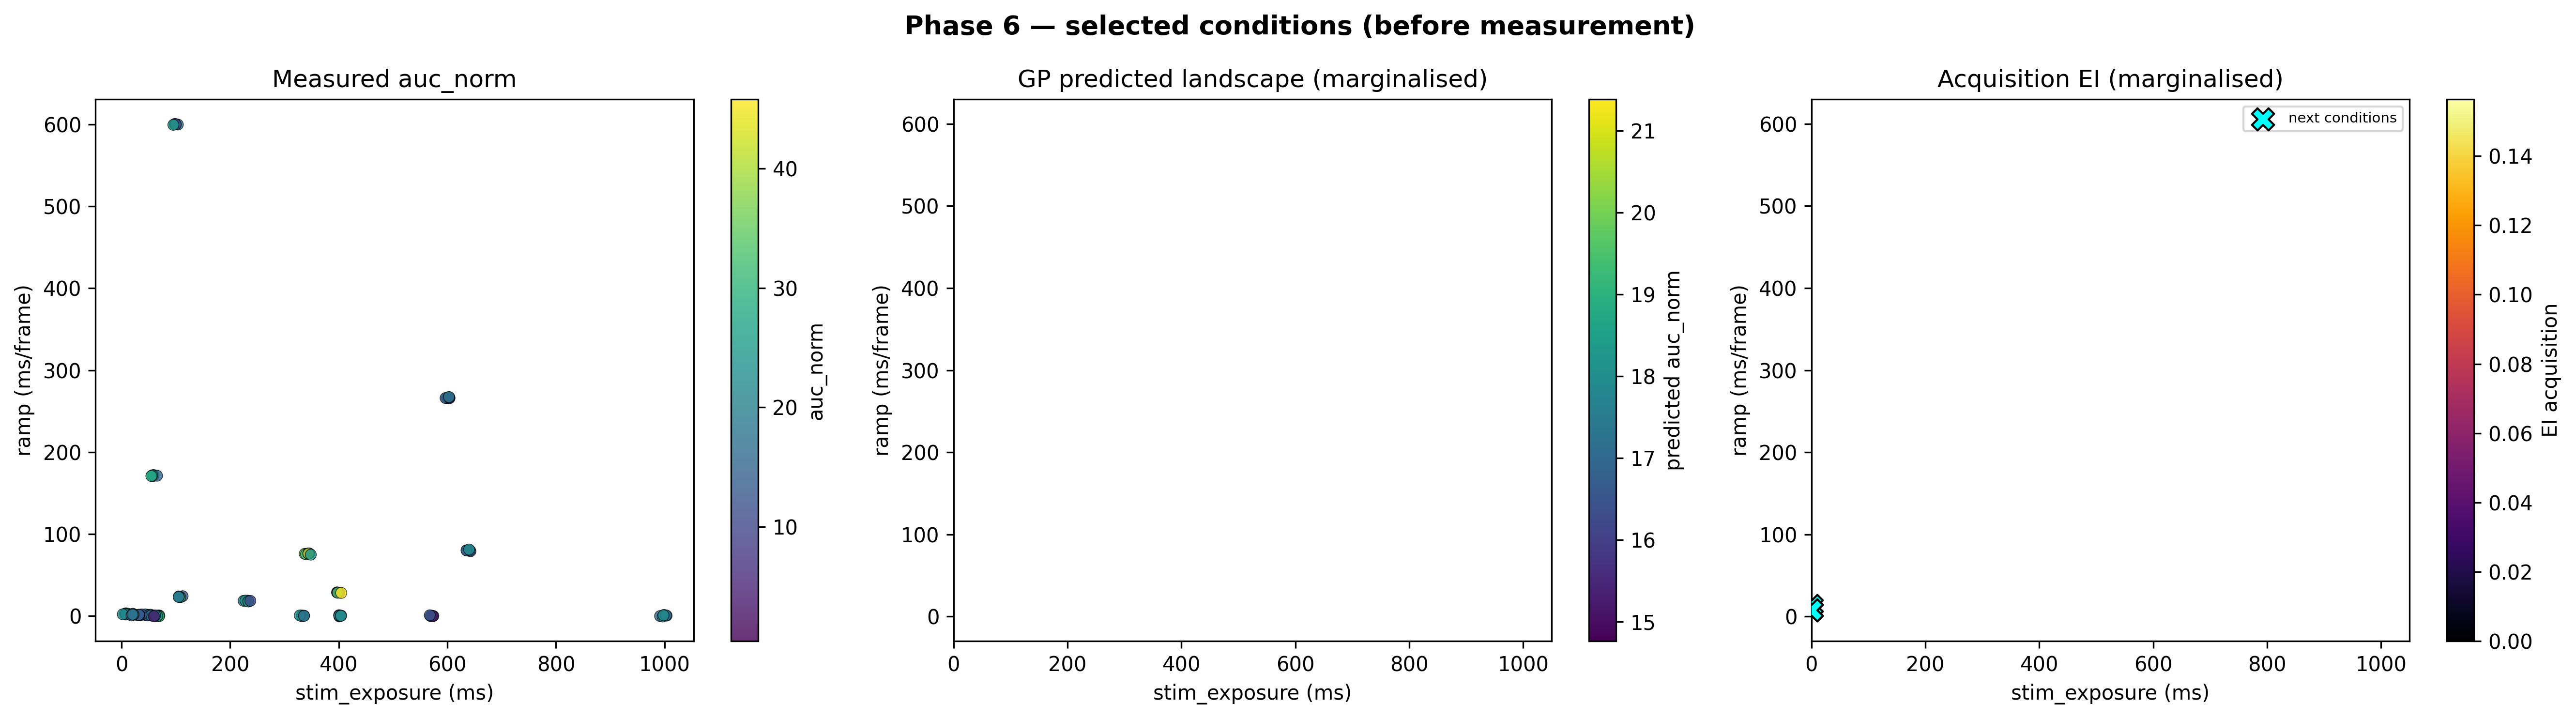

    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.00, pulse_interval=8: n_pulses=8 -> base=500.0ms, ramp=0.00ms/pulse, peak=500.0ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.00, pulse_interval=13: n_pulses=5 -> base=800.0ms, ramp=0.00ms/pulse, peak=800.0ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.60, pulse_interval=8: n_pulses=8 -> base=200.0ms, ramp=85.71ms/pulse, peak=800.0ms
  Created 1620 events for phase 6
    Cond 0 (FOVs 108-113): stim_exposure=500ms, ramp=0ms/frame, pulse_interval=8min, n_pulses=8 (final exposure: 500ms)
    Cond 1 (FOVs 114-119): stim_exposure=800ms, ramp=0ms/frame, pulse_interval=13min, n_pulses=5 (final exposure: 800ms)
    Cond 2 (FOVs 120-125): stim_exposure=200ms, ramp=86ms/frame, pulse_interval=8min, n_pulses=8 (final exposure: 800ms)
  Phase 6: 17 FOVs, mean auc_norm=25.8014, max=40.0909


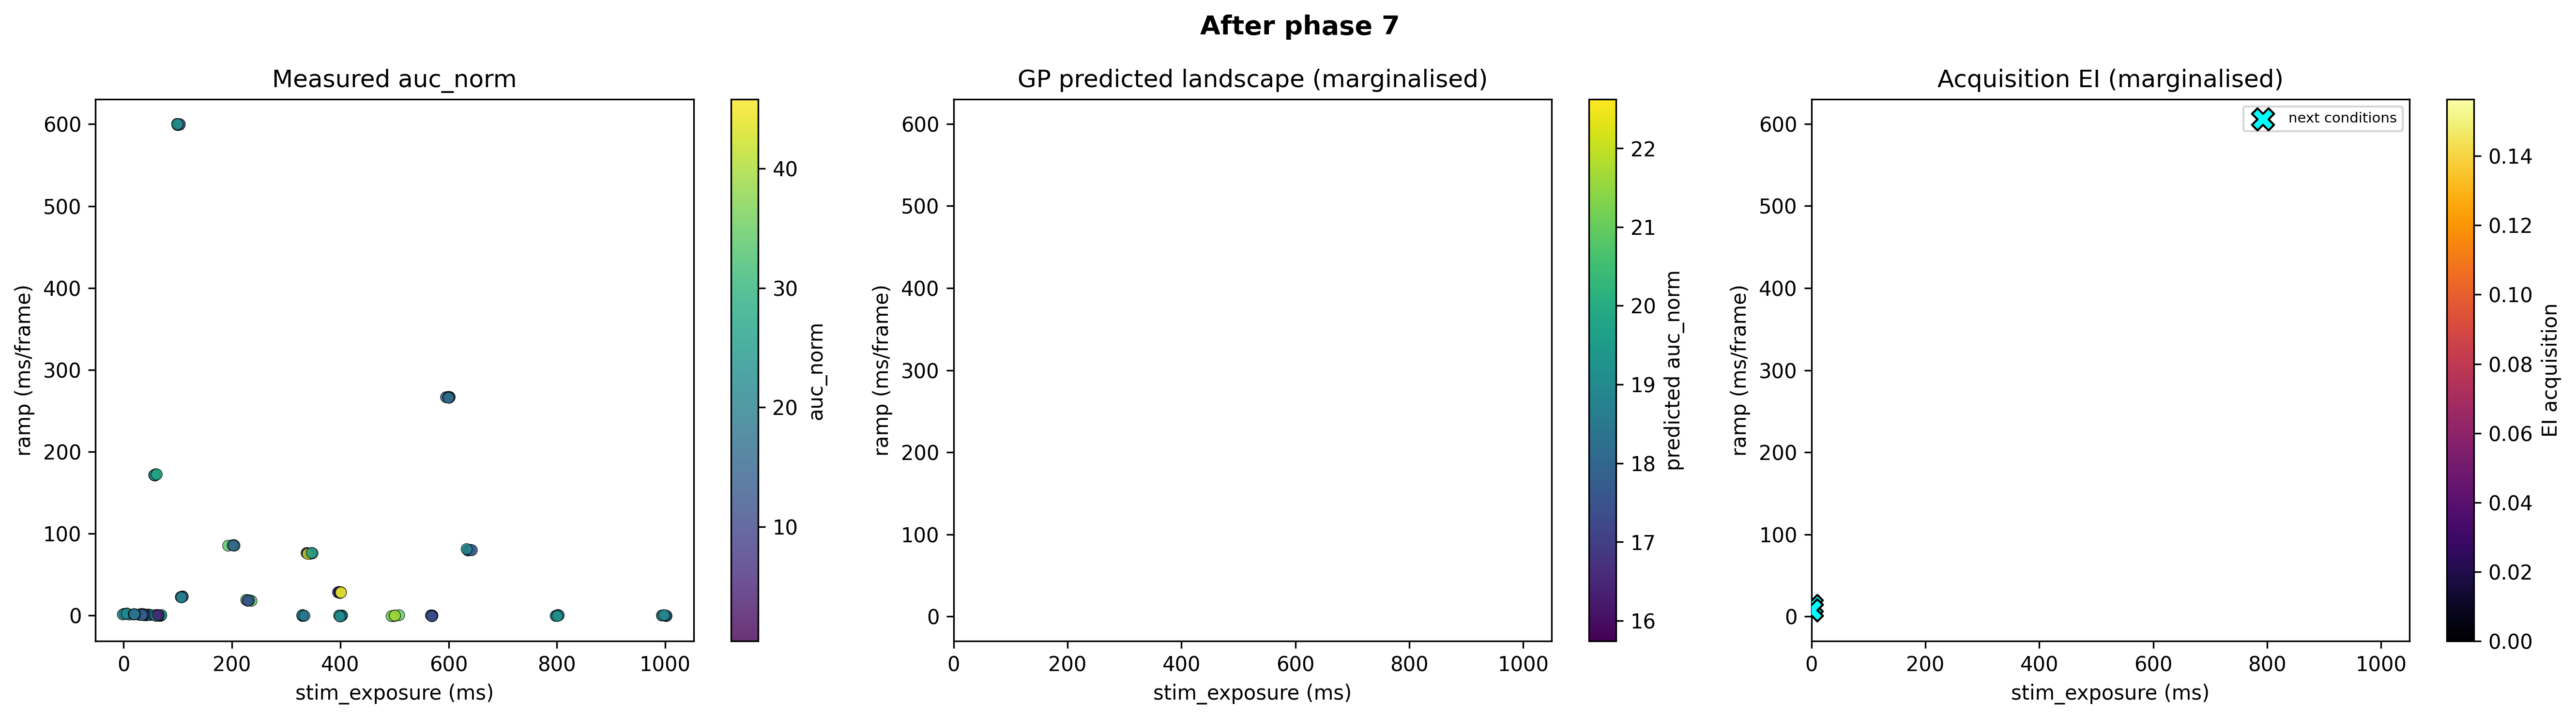


=== ComposedAgent: phase 8/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 7 — selected FOVs:
    D2_0000: 155 cells  cnr(mean=0.791, 73% below 0.95) (below min_cells)
    D2_0001: 89 cells  cnr(mean=0.871, 63% below 0.95) (below min_cells)
    D2_0002: 59 cells  cnr(mean=0.954, 42% below 0.95) (below min_cells)
    E2_0000: 141 cells  cnr(mean=0.919, 55% below 0.95) (below min_cells)
    E2_0001: 49 cells  cnr(mean=0.974, 39% below 0.95) (below min_cells)
    E2_0002: 35 cells  cnr(mean=1.059, 26% below 0.95) (below min_cells)
    E3_0000: 54 cells  cnr(mean=0.956, 37% below 0.95) (below min_cells)
    E3_0001: 46 cells  cnr(mean=0.925, 49% below 0.95) (below min_cells)
    E3_0002: 46 cells  cnr(mean=0.941, 46% below 0.95) (below min_cells)
    E4_0000: 110 cells  cnr(mean=0.879, 58% below 0.95) (below min_cells)
    E4_0001: 105 cells  cnr(mean=0.906, 50% below 0.95) (below min_cells)
    E4_0002: 77 cells  cnr(mean=0.903, 56% below 0.95) (below min_cells)
    E5_0000: 142 cells  cnr(mean=0.852, 70% below 0.95) (below min_cells)
    

sample: 100%|##########| 1200/1200 [00:07<00:00, 167.73it/s, 7 steps of size 4.89e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      4.49      3.35      3.68      0.90      8.09    644.49      1.00
k_length[1]      1.03      0.45      0.95      0.38      1.66    917.61      1.00
k_length[2]      6.25      4.51      4.87      1.03     11.51    692.65      1.00
k_length[3]      2.71      1.18      2.46      0.98      4.45    624.29      1.00
k_length[4]      1.69      0.74      1.58      0.61      2.71    782.48      1.00
    k_scale      0.94      0.50      0.82      0.34      1.54    574.08      1.00
      noise      0.45      0.07      0.44      0.34      0.57    901.22      1.00

Computing robust acquisition over 3184 scenarios (199 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.276561
  Robust acq stats: min=0.035003, max=0.272563
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 198 grid points x 16 covariate samples
  bes

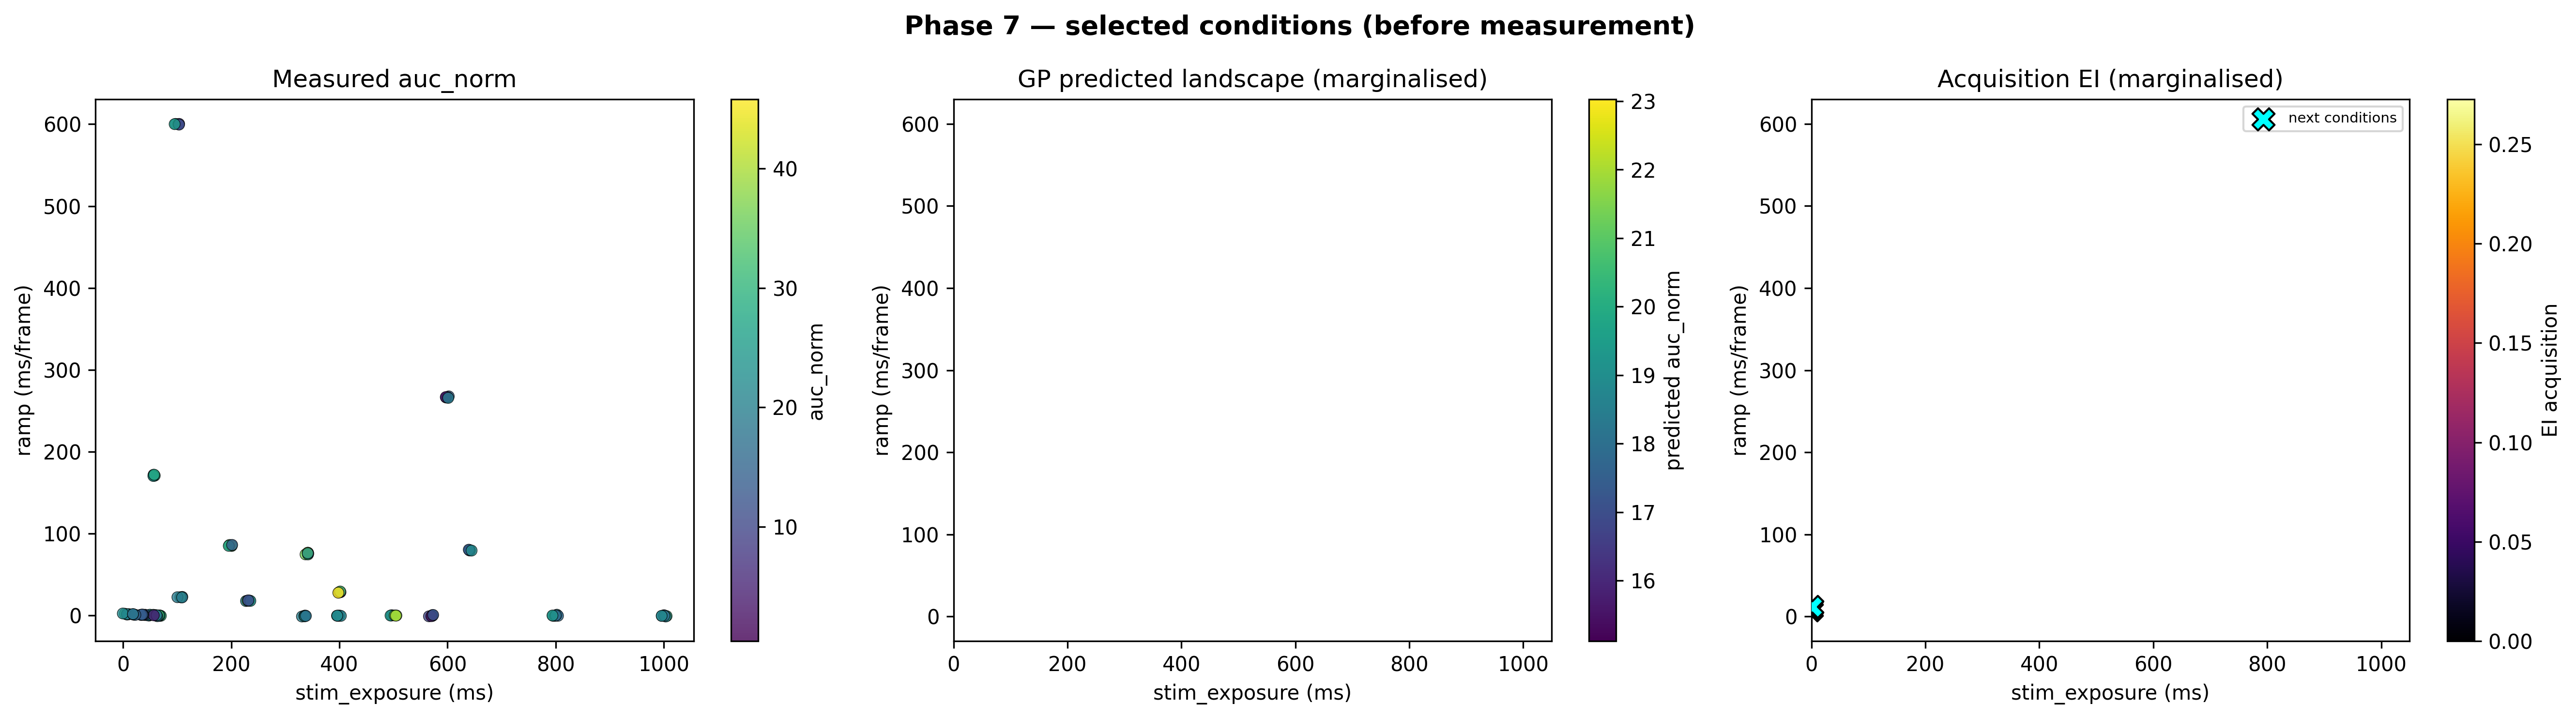

    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.10, pulse_interval=8: n_pulses=8 -> base=450.0ms, ramp=14.29ms/pulse, peak=550.0ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.10, pulse_interval=11: n_pulses=6 -> base=600.0ms, ramp=26.67ms/pulse, peak=733.3ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.70, pulse_interval=12: n_pulses=5 -> base=240.0ms, ramp=280.00ms/pulse, peak=1360.0ms
  Created 1620 events for phase 7
    Cond 0 (FOVs 126-131): stim_exposure=450ms, ramp=14ms/frame, pulse_interval=8min, n_pulses=8 (final exposure: 550ms)
    Cond 1 (FOVs 132-137): stim_exposure=600ms, ramp=27ms/frame, pulse_interval=11min, n_pulses=6 (final exposure: 733ms)
    Cond 2 (FOVs 138-143): stim_exposure=240ms, ramp=280ms/frame, pulse_interval=12min, n_pulses=5 (final exposure: 1360ms)
  Phase 7: 17 FOVs, mean auc_norm=21.5392, max=39.8219


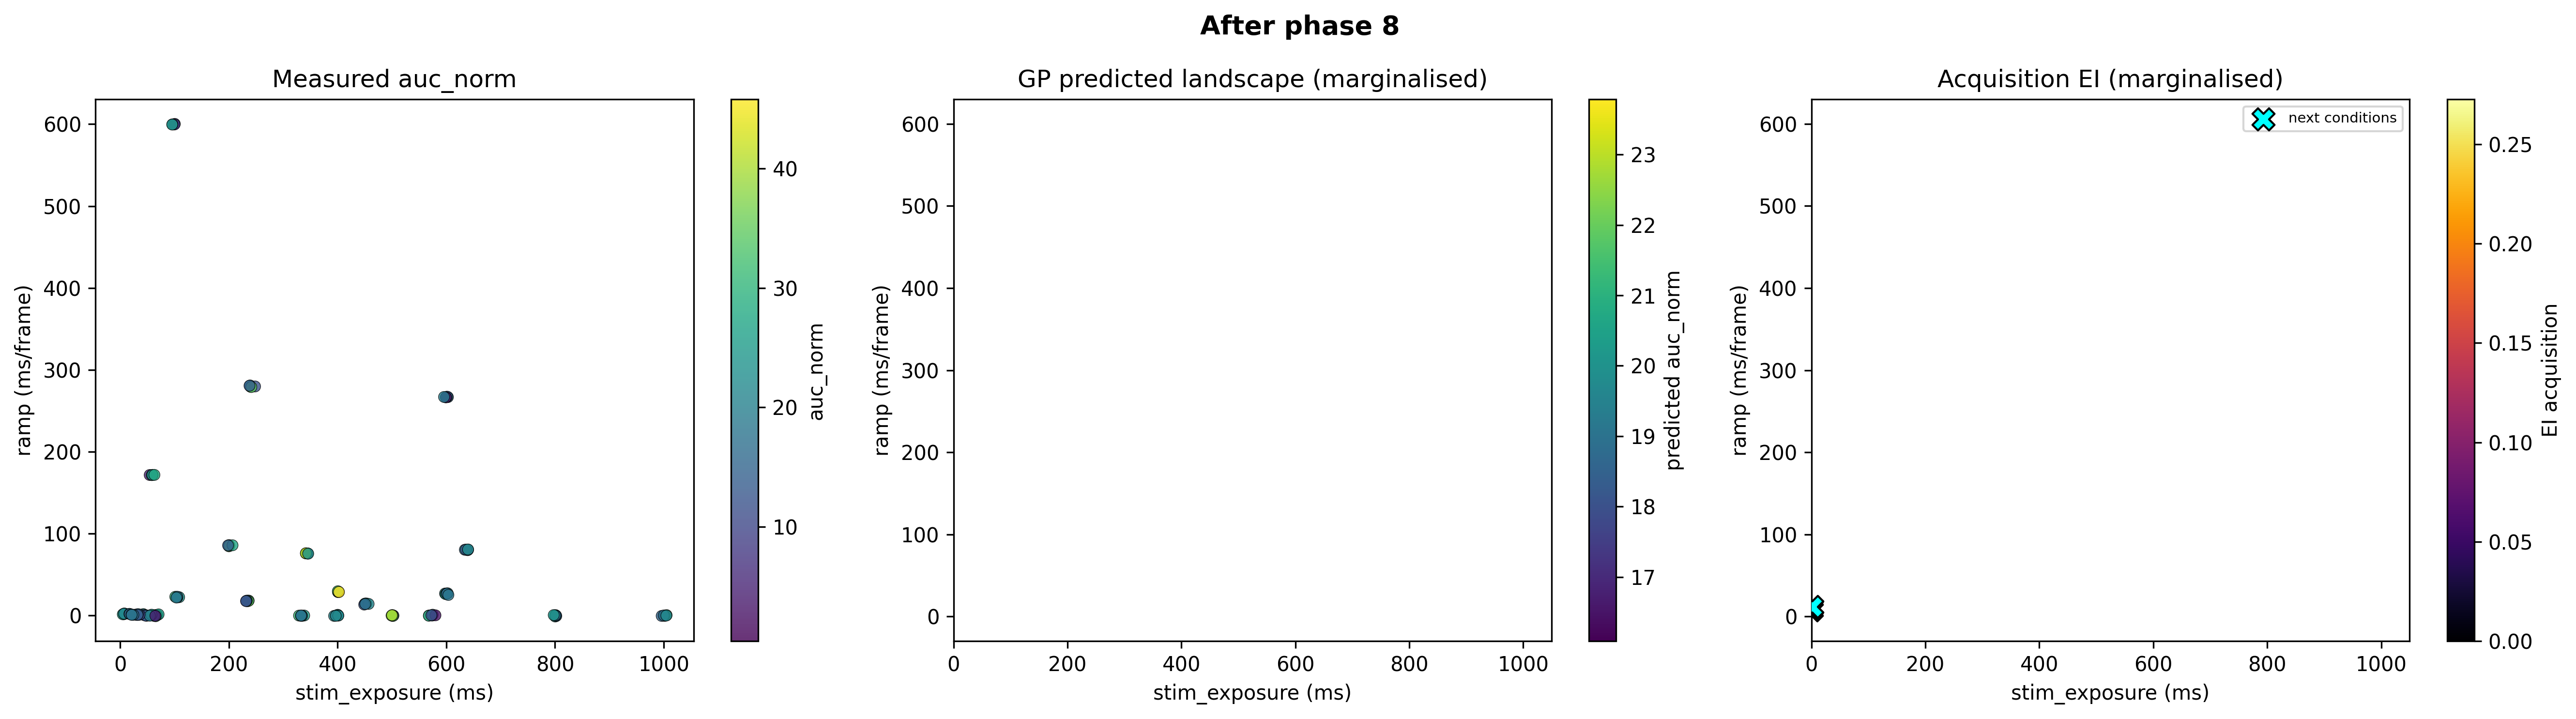


=== ComposedAgent: phase 9/13 ===
[FOVFinderAgent] Phase 8 — selected FOVs:
    E7_0000: 43 cells  cnr(mean=0.847, 79% below 0.95)
    E7_0001: 75 cells  cnr(mean=0.826, 68% below 0.95) (below min_cells)
    E7_0002: 63 cells  cnr(mean=0.889, 55% below 0.95) (below min_cells)
    E8_0000: 73 cells  cnr(mean=0.754, 79% below 0.95)
    E8_0001: 159 cells  cnr(mean=0.710, 82% below 0.95)
    E8_0002: 99 cells  cnr(mean=0.804, 68% below 0.95) (below min_cells)
    E9_0000: 50 cells  cnr(mean=0.810, 76% below 0.95)
    E9_0001: 192 cells  cnr(mean=0.700, 86% below 0.95)
    E9_0002: 90 cells  cnr(mean=0.864, 66% below 0.95) (below min_cells)
    E10_0000: 185 cells  cnr(mean=0.667, 89% below 0.95)
    E10_0001: 199 cells  cnr(mean=0.677, 85% below 0.95)
    E10_0002: 106 cells  cnr(mean=0.785, 73% below 0.95) (below min_cells)
    E11_0000: 120 cells  cnr(mean=0.804, 75% below 0.95)
    E11_0001: 115 cells  cnr(mean=0.816, 68% below 0.95) (below min_cells)
    E11_0002: 72 cells  cnr(mean=

sample: 100%|##########| 1200/1200 [00:11<00:00, 103.13it/s, 7 steps of size 5.48e-01. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      4.17      2.77      3.54      1.10      7.37    636.68      1.00
k_length[1]      1.02      0.44      0.95      0.37      1.54    885.42      1.00
k_length[2]      7.09      5.06      5.57      1.77     13.63    623.24      1.00
k_length[3]      3.02      1.21      2.82      1.27      4.90    845.77      1.00
k_length[4]      2.03      0.82      1.88      0.76      3.14    810.01      1.00
    k_scale      1.07      0.54      0.94      0.38      1.84    629.50      1.00
      noise      0.42      0.06      0.42      0.32      0.52   1049.37      1.00

Computing robust acquisition over 3136 scenarios (196 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.208099
  Robust acq stats: min=0.012703, max=0.247159
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 195 grid points x 16 covariate samples
  bes

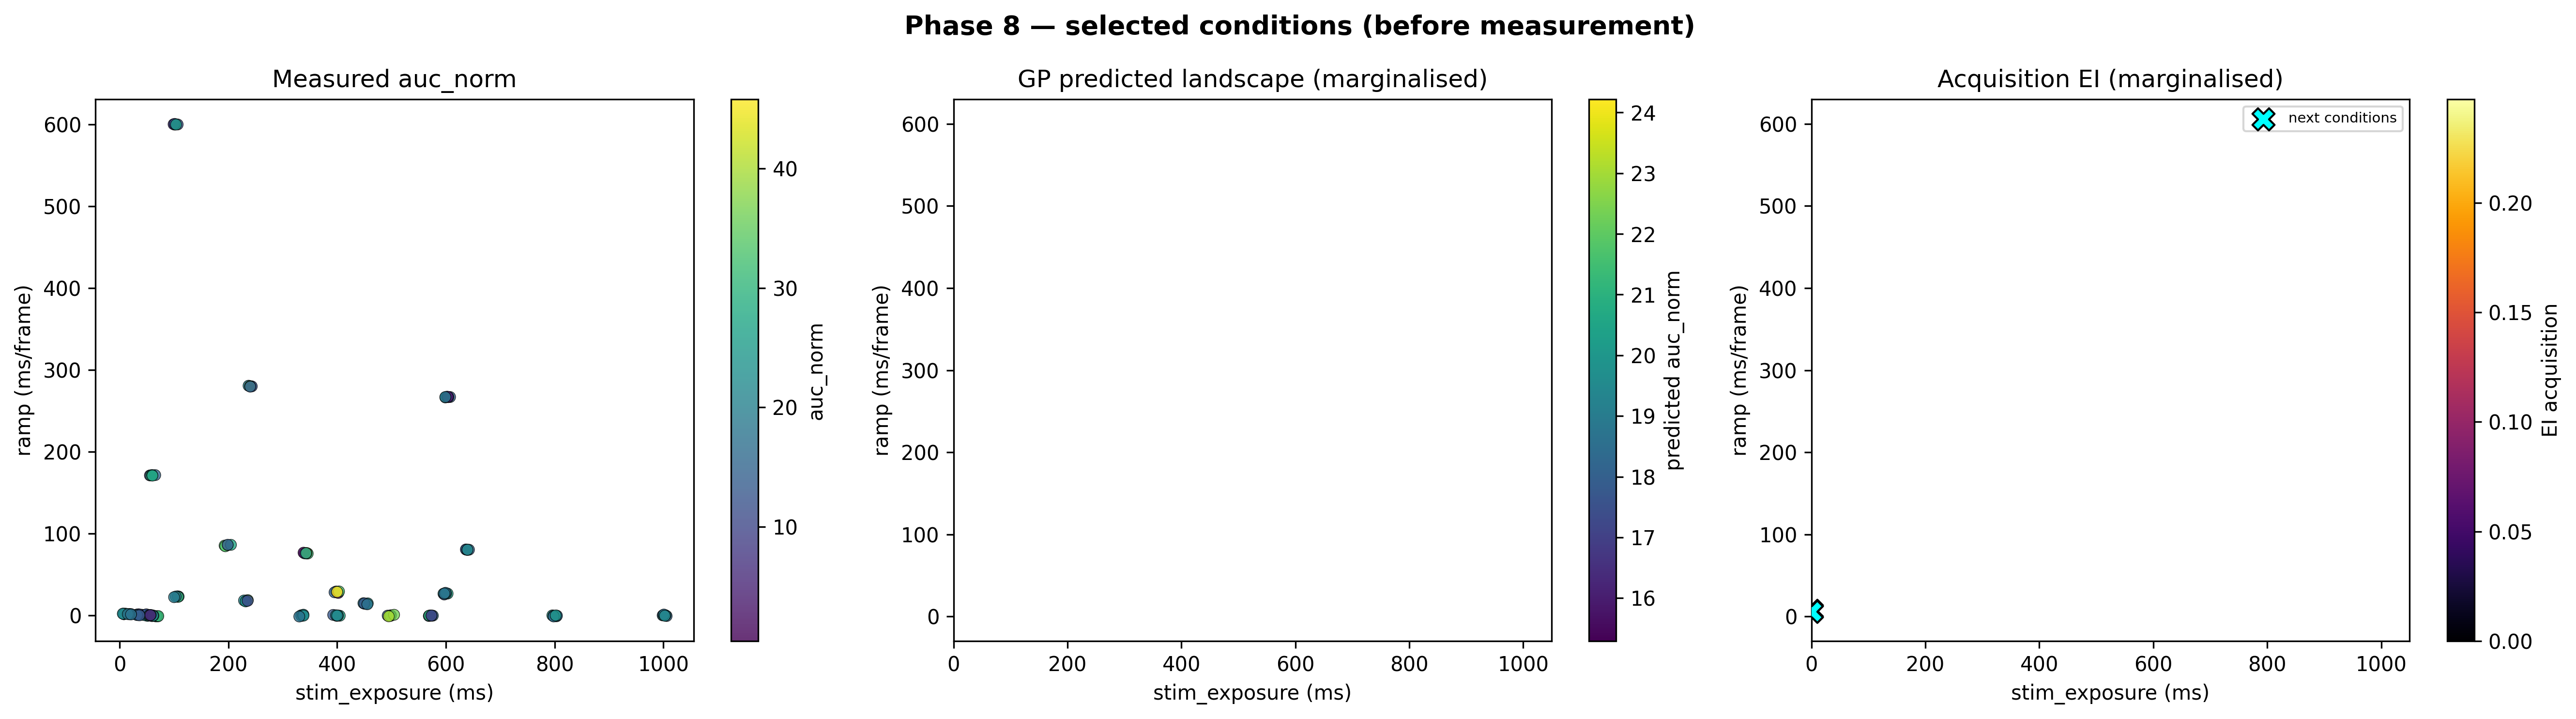

    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.00, pulse_interval=7: n_pulses=9 -> base=444.4ms, ramp=0.00ms/pulse, peak=444.4ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.10, pulse_interval=6: n_pulses=10 -> base=360.0ms, ramp=8.89ms/pulse, peak=440.0ms
    [budget reparam] light_budget=4000ms (pinned), ramp_fraction=0.20, pulse_interval=6: n_pulses=10 -> base=320.0ms, ramp=17.78ms/pulse, peak=480.0ms
  Created 1620 events for phase 8
    Cond 0 (FOVs 144-149): stim_exposure=444ms, ramp=0ms/frame, pulse_interval=7min, n_pulses=9 (final exposure: 444ms)
    Cond 1 (FOVs 150-155): stim_exposure=360ms, ramp=9ms/frame, pulse_interval=6min, n_pulses=10 (final exposure: 440ms)
    Cond 2 (FOVs 156-161): stim_exposure=320ms, ramp=18ms/frame, pulse_interval=6min, n_pulses=10 (final exposure: 480ms)


In [ ]:
# --- v13 phase-0 gate: starvation monitor on the sacrificial well ----------
# Replaces the old fixed "sleep until morning" wait.  The monitor images
# WELLS[0] every 20 min and returns once 75 % of cells have CNR < 1.0
# (cells starved down) or after a 20 h timeout.

# Disconnect napari live view so it does not interfere with the engine.
try:
    mm_wdg._core_link.cleanup()
except Exception:
    pass

mon_result = monitor.run()  # BLOCKS until ready / timeout
print(
    f"\n[monitor] triggered={mon_result['triggered']}  "
    f"after {mon_result['elapsed_min']:.0f} min  "
    f"({mon_result['n_rounds']} rounds)"
)
if not mon_result["triggered"]:
    print(
        "[monitor] WARNING: readiness threshold not reached before timeout. "
        "Inspect condition_monitor.parquet before trusting the run."
    )

# --- Run the composed (FOV finder + BO) loop on the fresh wells ------------
# Each phase: FOVFinder picks 18 FOVs in 6 fresh wells (from WELLS[1:]),
# then BudgetOscillationBO runs one batch BO iteration over them.  The GP
# accumulates observations across all phases.
composed_agent.run()

In [ ]:
# Post-processing: merge per-FOV tracks
utils.generate_exp_data_from_tracks(path)

## Visualise results

In [ ]:
# --- v13 results: measured auc_norm over the 2-D (ramp_fraction x pulse_interval) grid ---
if agent.df_results is not None and not agent.df_results.empty:
    df = agent.df_results
    obj_name = agent.objective_metric.name  # "auc_norm"

    vmin = float(df[obj_name].min())
    vmax = float(df[obj_name].max())

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # --- per-FOV scatter (jittered so overlapping FOVs are visible) ---
    ax = axes[0]
    _rng = np.random.default_rng(0)
    jx = _rng.normal(0, 0.02, size=len(df))
    jy = _rng.normal(0, 0.15, size=len(df))
    sc = ax.scatter(
        df["ramp_fraction"] + jx,
        df["pulse_interval"] + jy,
        c=df[obj_name],
        cmap="viridis",
        s=40,
        edgecolors="k",
        linewidths=0.5,
        vmin=vmin,
        vmax=vmax,
    )
    fig.colorbar(sc, ax=ax, label=obj_name)
    ax.set_xlabel("ramp_fraction")
    ax.set_ylabel("pulse_interval (frames)")
    ax.set_title(f"Per-FOV {obj_name}  (n_FOVs={len(df)})")

    # --- per-condition mean (marker size = n_FOVs) ---
    ax = axes[1]
    cond = (
        df.groupby(["ramp_fraction", "pulse_interval"])
        .agg(mean_obj=(obj_name, "mean"), n_fovs=(obj_name, "count"))
        .reset_index()
    )
    sc = ax.scatter(
        cond["ramp_fraction"],
        cond["pulse_interval"],
        c=cond["mean_obj"],
        s=cond["n_fovs"] * 30,
        cmap="viridis",
        edgecolors="k",
        linewidths=0.5,
        vmin=vmin,
        vmax=vmax,
    )
    fig.colorbar(sc, ax=ax, label=f"mean {obj_name}")
    ax.set_xlabel("ramp_fraction")
    ax.set_ylabel("pulse_interval (frames)")
    ax.set_title("Per-condition mean  (marker size = n_FOVs)")

    fig.suptitle(
        f"Measured {obj_name}  --  fixed budget {FIXED_LIGHT_BUDGET_MS:.0f} ms",
        fontsize=12,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    # --- convergence ---
    if agent._iteration_means:
        fig, ax = plt.subplots(figsize=(8, 5))
        means = np.array(agent._iteration_means)
        ax.plot(means, "o-", alpha=0.5, label="iteration mean")
        ax.plot(
            np.maximum.accumulate(means), "s-", color="red", label="cumulative best"
        )
        ax.set_xlabel("Iteration")
        ax.set_ylabel(obj_name)
        ax.set_title("BO convergence")
        ax.legend()
        plt.tight_layout()
        plt.show()

    # --- best condition by the configured BO objective ---
    cond_all = (
        df.groupby(["ramp_fraction", "pulse_interval"])
        .agg(
            mean_obj=(obj_name, "mean"),
            mean_auc=("auc_above_baseline", "mean"),
            n_fovs=(obj_name, "count"),
            mean_base_exposure=("stim_exposure", "mean"),
            mean_ramp=("ramp", "mean"),
        )
        .reset_index()
    )
    best = cond_all.loc[cond_all["mean_obj"].idxmax()]
    print(f"\nBest condition by {obj_name} (mean across FOVs):")
    print(f"  ramp_fraction           = {best['ramp_fraction']:.2f}")
    print(f"  pulse_interval          = {int(best['pulse_interval'])} frames")
    print(f"  -> derived base_exp     = {best['mean_base_exposure']:.1f} ms")
    print(f"  -> derived ramp         = {best['mean_ramp']:.2f} ms/pulse")
    print(f"  mean {obj_name}         = {best['mean_obj']:.4f}")
    print(f"  mean auc_above_baseline = {best['mean_auc']:.4f}")
    print(f"  tested on {int(best['n_fovs'])} FOVs")
else:
    print("No data collected yet.")

In [ ]:
# GP-predicted 2-D landscape, marginalised over covariates the SAME way the
# BO acquisition does (average GP predictions over empirical covariate samples).
import gpax
import gpax.utils
from faro.agents.bo_optimization_sparse import _safe_batch_size

if agent.model is not None and agent.x is not None:
    obj_name = agent.objective_metric.name
    rng_key, rng_key_pred = gpax.utils.get_keys()

    # BO grid axes (control space): column 0 = ramp_fraction, 1 = pulse_interval.
    rf_vals = np.unique(agent.x_total_linespace[:, 0])
    pi_vals = np.unique(agent.x_total_linespace[:, 1])
    n_r, n_p = len(rf_vals), len(pi_vals)

    df = agent.df_results
    n_cov_samples = 50
    cov_vals_full = df[[c.name for c in agent.bo_covariates]].to_numpy(dtype=float)
    if cov_vals_full.shape[0] == 0:
        raise RuntimeError("No covariate observations available for marginalisation.")
    _rng = np.random.default_rng(0)
    cov_samples = cov_vals_full[_rng.integers(0, cov_vals_full.shape[0], n_cov_samples)]

    ctrl_grid = np.array([[r, p] for r in rf_vals for p in pi_vals])
    n_grid = ctrl_grid.shape[0]
    x_full = np.hstack(
        [
            np.repeat(ctrl_grid, n_cov_samples, axis=0),
            np.tile(cov_samples, (n_grid, 1)),
        ]
    )
    x_full_scaled = agent._x_scaler.transform(x_full)

    bs = _safe_batch_size(np.asarray(x_full_scaled).shape[0], 2000)
    y_pred_scaled, _ = agent.model.predict_in_batches(
        rng_key_pred,
        x_full_scaled,
        batch_size=bs,
        n=1,
        noiseless=True,
    )
    y_pred = agent._y_scaler.inverse_transform(
        np.asarray(y_pred_scaled).reshape(-1, 1)
    ).flatten()
    Y = y_pred.reshape(n_grid, n_cov_samples).mean(axis=1).reshape(n_r, n_p)

    flat = int(np.argmax(Y))
    ri, pii = np.unravel_index(flat, (n_r, n_p))
    opt_rf, opt_pi, opt_val = rf_vals[ri], pi_vals[pii], Y[ri, pii]

    fig, ax = plt.subplots(figsize=(9, 6))
    cf = ax.contourf(rf_vals, pi_vals, Y.T, levels=20, cmap="viridis")
    fig.colorbar(cf, ax=ax, label=f"predicted {obj_name}")
    ax.scatter(
        df["ramp_fraction"],
        df["pulse_interval"],
        c=df[obj_name],
        cmap="viridis",
        s=30,
        edgecolors="white",
        linewidths=0.5,
        zorder=5,
    )
    ax.scatter(
        opt_rf,
        opt_pi,
        c="red",
        s=260,
        marker="*",
        edgecolors="black",
        linewidths=2,
        zorder=10,
        label=f"opt: rf={opt_rf:.2f}, pi={int(opt_pi)}\npred={opt_val:.3f}",
    )
    ax.set_xlabel("ramp_fraction")
    ax.set_ylabel("pulse_interval (frames)")
    ax.set_title(
        f"GP-predicted {obj_name} landscape  --  fixed budget "
        f"{FIXED_LIGHT_BUDGET_MS:.0f} ms\n"
        f"(marginalised over {n_cov_samples} covariate samples)"
    )
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

    print(
        f"GP-predicted optimum: ramp_fraction={opt_rf:.2f}, "
        f"pulse_interval={int(opt_pi)}, predicted {obj_name}={opt_val:.4f}"
    )
else:
    print("GP not fit yet -- run the BO first.")

In [ ]:
# Covariate effects on the configured BO objective (per FOV)
if agent.df_results is not None and not agent.df_results.empty:
    df = agent.df_results
    obj_name = agent.objective_metric.name

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(df["n_cells"], df[obj_name], alpha=0.6, s=20)
    axes[0].set_xlabel("n_cells per FOV")
    axes[0].set_ylabel(obj_name)
    axes[0].set_title(f"Cell density vs {obj_name}")

    axes[1].scatter(df["optortk_expression"], df[obj_name], alpha=0.6, s=20)
    axes[1].set_xlabel("optoRTK expression (mCitrine intensity)")
    axes[1].set_ylabel(obj_name)
    axes[1].set_title(f"optoRTK expression vs {obj_name}")

    axes[2].scatter(df["baseline_cnr"], df[obj_name], alpha=0.6, s=20)
    axes[2].set_xlabel("baseline_cnr (pre-stim CNR)")
    axes[2].set_ylabel(obj_name)
    axes[2].set_title(f"Baseline CNR vs {obj_name}")

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import glob, os

# Per-phase delta of conditions tested.  Each checkpoint stores the
# cumulative df_results, so phase N's new conditions = rows in ckpt N
# that aren't in ckpt N-1.  Rendered in BO-axis terms (ramp_fraction,
# pulse_interval) -- light_budget is pinned in v13 so it is not shown.
RUN_PATH = path  # storage_path of this notebook's run
ckpts = sorted(
    glob.glob(os.path.join(RUN_PATH, "checkpoints", "bo_results_phase_*.parquet"))
)

prev_len = 0
summary = []
for f in ckpts:
    phase_id = int(os.path.basename(f).split("_")[-1].split(".")[0])
    df = pd.read_parquet(f)
    df_new = df.iloc[prev_len:]
    prev_len = len(df)
    conds = (
        df_new[["ramp_fraction", "pulse_interval"]].drop_duplicates().values.tolist()
    )
    summary.append(
        {
            "phase_id": phase_id,
            "n_fovs": len(df_new),
            "conditions": [f"(frac={r:.2f}, pi={int(p)})" for r, p in conds],
        }
    )

for row in summary:
    print(
        f"Phase {row['phase_id']:2d}  ({row['n_fovs']:2d} FOVs): "
        f"{'  |  '.join(row['conditions'])}"
    )

In [ ]:
# --- v13 stopping-criterion diagnostic (PRINTED, not enforced) -------------
# A practical convergence check: after each phase, look at the cumulative-best
# objective.  We FLAG the phase where the BO would have been stopped, but the
# run is NOT halted -- this is a diagnostic for the midterm, to show how many
# phases added little.
if agent.df_results is not None and agent._iteration_means:
    means = np.array(agent._iteration_means)
    cum_best = np.maximum.accumulate(means)

    REL_TOL = 0.02  # < 2 % improvement in cumulative best ...
    PATIENCE = 3  # ... for 3 consecutive phases => "converged"

    stalled = 0
    stop_phase = None
    print("Phase | iter-mean | cum-best | d(cum-best) | status")
    print("-" * 58)
    for i in range(len(means)):
        if i == 0:
            delta = float("nan")
        else:
            denom = abs(cum_best[i - 1]) if cum_best[i - 1] != 0 else 1.0
            delta = (cum_best[i] - cum_best[i - 1]) / denom
            stalled = stalled + 1 if delta < REL_TOL else 0
        flag = ""
        if stop_phase is None and stalled >= PATIENCE:
            stop_phase = i
            flag = "  <-- would STOP here"
        print(
            f"{i:5d} | {means[i]:9.4f} | {cum_best[i]:8.4f} | "
            f"{delta:11.4f} | {flag}"
        )

    if stop_phase is not None:
        wasted = len(means) - 1 - stop_phase
        print(
            f"\nStopping criterion: cumulative best improved < {REL_TOL:.0%} "
            f"for {PATIENCE} consecutive phases at phase {stop_phase}. "
            f"{wasted} later phase(s) (~{wasted * N_FOVS} FOVs) added little "
            f"-- NOT enforced."
        )
    else:
        print(
            f"\nStopping criterion never met: the BO was still improving at "
            f"the last phase (no plateau of {PATIENCE} phases)."
        )
else:
    print("No iteration history yet -- run the BO first.")